# MetroPT-3 — Exploratory Data Analysis

**PdM-Agent · AI 894 capstone, Group 6 (Project 06)**
Rosh Chathoth Sreedharan · Ashok Reddy Buthukuri · Gayatri Suresh Chaudhari

This notebook is our first structured pass over the MetroPT-3 dataset before any modeling work.
It has seven jobs:

1. Settle the **sampling rate** from the file's own timestamps (our sources disagree between 0.1 Hz and 1 Hz).
2. Map **coverage and gaps** across the seven-month recording period.
3. Find the **artifacts and unlabeled episodes** (logger freezes, continuous load with no report) that would otherwise leak into training and evaluation.
4. Characterize each of the 15 signals, and how they behave in **healthy vs. failure** periods.
5. Identify **healthy windows** suitable for fitting the anomaly detector.
6. Produce the facts that go into **`asset_profile.yaml` and `events.yaml`** (signals, units, sampling interval, masks, failure labels).
7. Turn the raw file into **model-ready windows and features** (Sections 7–8), saved to `data/processed/` for the modeling phase.

Everything downstream — detector interface, MCP diagnostic checks, evaluation — reads from what this notebook establishes.

**Revised and extended Sep 27, 2026.** We checked the Sep 24 run line by line against the raw file
and the UCI description PDF. Most of it held. The cycling precursor and the two unlabeled episodes
did not, and a few smaller readings changed; everything is corrected in place (see *What changed*
below), and the checks that caught it are now part of the notebook. Sections 7 and 8, added the same
day, cover data preprocessing and feature engineering. Re-running reproduces the numbers in the text.

### What changed in this revision

Corrected:

- **COMP cycling is not a precursor.** Every day above 300 cycles falls inside a logger freeze, when
  the analog channels stop updating and COMP chatters. With freezes masked, no failure is preceded
  by elevated cycling (Sections 2.2 and 4).
- **The "unlabeled episodes" of Jun 13 and Jul 25 were misread dates.** The spikes are on Jun 12
  and Jul 21–22, and both are freezes.
- **The 9–13 s "jitter" is two things.** Real steps are 9–10 s; the 11–13 s steps are the freezes.
- **The off-load current rise before F3** in our Sep 19 notes is not in the data (Section 5.2).

Added:

- A gap taxonomy and the timezone check (2.1); logger-freeze detection and the ten masks (2.2).
- The DV_pressure regime change at the Jun 8 repair (3.1) and the TP3–Reservoirs check (3.2).
- Digital channels read by operating state (4.1).
- Six continuous-load episodes with no report (5.1), and the F4 lead-up with an indicative
  load-share rule (5.2).
- Healthy data counted at window level under the `events.yaml` v0.2 exclusions (Section 6).
- Data preprocessing (Section 7) and feature engineering (Section 8), with the outputs saved to
  `data/processed/`.

## Dataset notes

MetroPT-3 (UCI ML Repository, dataset 791, CC BY 4.0) contains readings from the Air Production Unit (APU)
compressor of a Metro do Porto train, recorded from February 1 to September 1, 2020: 7 analog and 8 digital channels,
1,516,948 records. Failure information comes from the operator's maintenance reports, tabulated in the
accompanying paper (Veloso et al., 2022, *The MetroPT dataset for predictive maintenance*) and in the
UCI description PDF that ships with the data (`data/Data Description_Metro.pdf`).

Two numbers about this dataset circulate in our own documents — 1,516,948 records and 15.2 M readings.
The load cell below checks the file itself; 1,516,948 is the row count we hold ourselves to. The PDF's
15,169,480 instances is exactly ten times the file: the count at the original 1 Hz, before the data were
released at 0.1 Hz.

### Signal dictionary

Descriptions paraphrased from the dataset paper. The last column is what the data shows (Sections 3
and 4); where the two disagree, the diagnostic checks follow the data.

| Signal | Type | Unit | Description (per Veloso et al., 2022) | What the data shows |
|---|---|---|---|---|
| TP2 | analog | bar | Pressure at the compressor | — |
| TP3 | analog | bar | Pressure at the pneumatic panel | Same as Reservoirs to 0.01 bar (3.2) |
| H1 | analog | bar | Pressure drop at the cyclonic separator filter | Mirrors TP2 (r = −0.96) |
| DV_pressure | analog | bar | Pressure drop at the towers' discharge | Flat after the Jun 8 repair (3.1) |
| Reservoirs | analog | bar | Downstream reservoir pressure (tracks TP3) | Same as TP3 |
| Oil_temperature | analog | °C | Compressor oil temperature | — |
| Motor_current | analog | A | Current of one motor phase (~0 off, ~4 A off-load, ~7 A under load) | — |
| COMP | digital | 0/1 | Air-intake valve signal; active when there is no air intake | As described: 0 while loading |
| DV_eletric | digital | 0/1 | Outlet valve signal; active when compressor runs under load | As described; a few hours read 1 with the motor off (5.2) |
| Towers | digital | 0/1 | Which air-drying tower is in service | Switches only under load |
| MPG | digital | 0/1 | Starts the compressor under load when pressure < 8.2 bar | Mirrors COMP |
| LPS | digital | 0/1 | Low-pressure switch; activates below 7 bar | Fires with Reservoirs below 7 bar |
| Pressure_switch | digital | 0/1 | Detects discharge in the drying towers | 0 is the rare event, tied to load |
| Oil_level | digital | 0/1 | Active when oil level is below expected | 0 almost only in August; never during a leak |
| Caudal_impulses | digital | 0/1 | Flowmeter (airflow) pulse signal | 0 only in March |

(The spellings `DV_eletric` and `Caudal_impulses` are the dataset's own.)

## 0 · Setup

Built to run in **Google Colab**: the data cell below fetches MetroPT-3 straight from the UCI
archive on first run (a one-time download of roughly 60 MB), so *Runtime → Run all* is enough.
Running locally works the same way; if you already have `MetroPT3(AirCompressor).csv`, put it next
to the notebook (or under `data/`) and the download is skipped.

The failure windows and repair times below come from the UCI description PDF, checked to the
minute on Sep 25. The exclusion lists (freeze masks, uncertain periods, grey period) are the
entries planned for `events.yaml` v0.2. Sections 2.2 and 5.1 re-derive the freeze masks and the six
load episodes from the data and print whether they still match; the heavy-LPS days and the grey
period are carried over as entered.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)

# --- data location: edit if your copy lives elsewhere -------------------
_CANDIDATES = [
    Path('MetroPT3(AirCompressor).csv'),
    Path('data/MetroPT3(AirCompressor).csv'),
    Path('../data/MetroPT3(AirCompressor).csv'),
    Path('/content/MetroPT3(AirCompressor).csv'),
]

EXPECTED_RECORDS = 1_516_948   # UCI dataset page (not 15.2 M)

ANALOG = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
          'Oil_temperature', 'Motor_current']
DIGITAL = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
           'Pressure_switch', 'Oil_level', 'Caudal_impulses']
UNITS = {'TP2': 'bar', 'TP3': 'bar', 'H1': 'bar', 'DV_pressure': 'bar',
         'Reservoirs': 'bar', 'Oil_temperature': 'degC', 'Motor_current': 'A'}

# Failure windows and repair times from the UCI description PDF
# (data/Data Description_Metro.pdf), checked to the minute on 2026-09-25.
# The PDF prints the second repair as "30Apr at 12:00"; it is 30 May.
# F1 has no repair time listed.
FAILURE_WINDOWS = [
    ('2020-04-18 00:00', '2020-04-18 23:59', 'Air leak 1'),
    ('2020-05-29 23:30', '2020-05-30 06:00', 'Air leak 2'),
    ('2020-06-05 10:00', '2020-06-07 14:30', 'Air leak 3'),
    ('2020-07-15 14:30', '2020-07-15 19:00', 'Air leak 4'),
]
REPAIRS = [None, '2020-05-30 12:00', '2020-06-08 16:00', '2020-07-16 00:00']
FAILURE_WINDOWS = [(pd.Timestamp(s), pd.Timestamp(e), n)
                   for s, e, n in FAILURE_WINDOWS]
REPAIRS = [pd.Timestamp(r) if r else None for r in REPAIRS]

In [2]:
# The entries planned for events.yaml v0.2 (build guide, R1a.1), restated so the
# notebook runs on its own. Sections 2.2 and 5.1 re-derive the freeze masks and
# the six load episodes from the data and print whether they still match.
T = pd.Timestamp

FREEZE_MASKS = [(T(s), T(e)) for s, e in [       # logger freezes (Section 2.2)
    ('2020-04-13 18:29:20', '2020-04-13 19:27:16'),
    ('2020-04-17 09:20:43', '2020-04-18 00:18:07'),
    ('2020-04-20 04:49:17', '2020-04-21 01:16:52'),
    ('2020-05-26 09:19:36', '2020-05-27 13:43:45'),
    ('2020-05-27 13:54:04', '2020-05-28 03:16:28'),
    ('2020-06-12 02:01:56', '2020-06-12 17:00:07'),
    ('2020-06-22 15:06:21', '2020-06-23 02:56:00'),
    ('2020-06-23 02:56:35', '2020-06-25 05:08:35'),
    ('2020-07-21 13:45:12', '2020-07-21 22:03:16'),
    ('2020-07-22 06:43:44', '2020-07-22 13:04:24'),
]]

UNCERTAIN = [(T(s), T(e), tag) for s, e, tag in [
    # heavy LPS activity with no report: whole days, end exclusive
    ('2020-04-25', '2020-04-28', 'lps_heavy'),
    ('2020-05-02', '2020-05-09', 'lps_heavy'),
    ('2020-06-30', '2020-07-03', 'lps_heavy'),
    # continuous load with no report (Section 5.1)
    ('2020-03-12 00:16', '2020-03-12 11:50', 'load_held'),
    ('2020-03-27 07:12', '2020-03-27 11:38', 'load_held'),
    ('2020-03-28 23:21', '2020-03-29 19:49', 'probable_leak'),
    ('2020-04-12 11:50', '2020-04-12 23:36', 'load_held'),
    ('2020-05-13 13:45', '2020-05-14 00:57', 'probable_leak'),
    ('2020-05-19 22:20', '2020-05-20 19:48', 'probable_leak'),
]]

GREY = [(T('2020-06-08 11:48'), T('2020-06-08 16:00'))]   # data resume before the F3 repair

BUFFER_BEFORE = pd.Timedelta(days=7)    # healthy_buffer.before_failure
BUFFER_AFTER = pd.Timedelta(hours=48)   # healthy_buffer.after_repair, from the repair hour
REGIME_SPLITS = [T('2020-03-01'), T('2020-06-08 16:00')]   # light duty | normal | DV_pressure flat

In [3]:
# Get the data. In Colab (or anywhere with internet) this downloads the
# official zip from UCI on first run; it is skipped once the CSV exists.
import io
import zipfile
import urllib.request

if not any(p.exists() for p in _CANDIDATES):
    print('Downloading MetroPT-3 from the UCI archive ...')
    req = urllib.request.Request(
        'https://archive.ics.uci.edu/static/public/791/metropt+3+dataset.zip',
        headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as r:
        buf = io.BytesIO(r.read())
    data_dir = Path('data')
    data_dir.mkdir(exist_ok=True)
    with zipfile.ZipFile(buf) as z:
        member = next(m for m in z.namelist() if m.endswith('.csv'))
        extracted = Path(z.extract(member, data_dir))
    target = data_dir / 'MetroPT3(AirCompressor).csv'
    if extracted != target:
        extracted.rename(target)
    print(f'Saved {target}')

DATA_PATH = next((p for p in _CANDIDATES if p.exists()), _CANDIDATES[0])
print(f'Using: {DATA_PATH}')

Using: ../data/MetroPT3(AirCompressor).csv


In [4]:
# Chart style: one restrained palette, hairline grid, red reserved for failures.
SURFACE, GRID = '#fcfcfb', '#e1e0d9'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
CRITICAL = '#d03b3b'
DIVERGING = LinearSegmentedColormap.from_list(
    'div', ['#2a78d6', '#f0efec', '#d03b3b'])

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#c3c2b7', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.labelcolor': INK2, 'text.color': INK,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'figure.dpi': 110,
    'axes.prop_cycle': cycler(color=[BLUE, ORANGE, AQUA, YELLOW]),
})

def shade_failures(ax):
    # Red wash over the reported failure windows.
    for s, e, _ in FAILURE_WINDOWS:
        ax.axvspan(s, e, color=CRITICAL, alpha=0.18, lw=0)

## 1 · Load and first checks

Record count against the UCI figure, time span, and schema.

In [5]:
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

match = 'match' if len(df) == EXPECTED_RECORDS else 'MISMATCH -- investigate'
print(f'File:    {DATA_PATH}')
print(f'Records: {len(df):,}  (expected {EXPECTED_RECORDS:,} -> {match})')
print(f'Span:    {df.timestamp.min()}  ->  {df.timestamp.max()}')
print(f'Memory:  {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB')
missing_cols = [c for c in ANALOG + DIGITAL if c not in df.columns]
print('Schema:  all 15 expected signals present' if not missing_cols
      else f'Schema:  MISSING {missing_cols} -- continuing with what is present')

# If the schema ever drifts, analyze the columns that exist rather than crash.
ANALOG = [c for c in ANALOG if c in df.columns]
DIGITAL = [c for c in DIGITAL if c in df.columns]
df.head()

File:    ../data/MetroPT3(AirCompressor).csv
Records: 1,516,948  (expected 1,516,948 -> match)
Span:    2020-02-01 00:00:00  ->  2020-09-01 03:59:50
Memory:  194 MB
Schema:  all 15 expected signals present


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [6]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'nulls': df.isna().sum(),
    'unique': df.nunique(),
})
summary

,dtype,non_null,nulls,unique
timestamp,datetime64[ns],1516948,0,1516948
TP2,float64,1516948,0,5257
TP3,float64,1516948,0,3683
H1,float64,1516948,0,2665
DV_pressure,float64,1516948,0,2257
Reservoirs,float64,1516948,0,3682
Oil_temperature,float64,1516948,0,2462
Motor_current,float64,1516948,0,1809
COMP,float64,1516948,0,2
DV_eletric,float64,1516948,0,2


In [7]:
# Integrity: digital channels binary? constant columns? duplicate timestamps?
issues = []
for c in DIGITAL:
    vals = set(df[c].dropna().unique())
    if not vals <= {0, 1}:
        issues.append((c, sorted(vals)[:10]))
print('All digital channels are strictly binary (0/1).' if not issues
      else f'Non-binary digital channels: {issues}')

const = [c for c in ANALOG + DIGITAL if df[c].nunique() <= 1]
print('Constant columns:', const if const else 'none')

dup_ts = int(df.timestamp.duplicated().sum())
print(f'Duplicated timestamps: {dup_ts:,}')

df[ANALOG].describe().T.round(2)

All digital channels are strictly binary (0/1).
Constant columns: none
Duplicated timestamps: 0


,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.37,3.25,-0.03,-0.01,-0.01,-0.01,10.68
TP3,1516948.0,8.98,0.64,0.73,8.49,8.96,9.49,10.30
H1,1516948.0,7.57,3.33,-0.04,8.25,8.78,9.37,10.29
DV_pressure,1516948.0,0.06,0.38,-0.03,-0.02,-0.02,-0.02,9.84
Reservoirs,1516948.0,8.99,0.64,0.71,8.49,8.96,9.49,10.30
Oil_temperature,1516948.0,62.64,6.52,15.40,57.78,62.70,67.25,89.05
Motor_current,1516948.0,2.05,2.30,0.02,0.04,0.04,3.81,9.30


## 2 · Sampling rate and coverage

Our sources disagreed between 1 Hz and 0.1 Hz. The timestamps settle it: the median delta is
10 s — an effective rate of **0.1 Hz**. Real steps are 9–10 s; the 11–13 s steps in the table
below are almost all logger freezes (Section 2.2). Windowing code should mask the freezes first,
then resample to a regular 10 s grid rather than assume one. This number goes straight into the
asset profile YAML, and the proposal's 1 Hz mention gets corrected to match.

Coverage is the other headline: about 82 % of the span is recorded, across 331 gaps totalling
roughly 38 days. Nearly half of the missing time is overnight stops, and most of the rest is 15 long
outages (Section 2.1). Several gaps exceed a full day, and a 21-hour gap starts just before the
third failure window ends — repair downtime, most likely. Windows that straddle a gap should be
dropped, not bridged.

In [8]:
dt = df.timestamp.diff().dt.total_seconds().dropna()
step = float(dt.median())

print('Most common timestamp deltas (seconds):')
print(dt.value_counts().head(8).rename('count').to_frame())
print()
print(f'Median delta: {step:g} s  ->  effective sampling rate {1 / step:.3g} Hz')

span_s = (df.timestamp.max() - df.timestamp.min()).total_seconds()
print(f'Signal time: {len(df):,} records x {step:g} s '
      f'= {len(df) * step / 86400:,.1f} days over a '
      f'{span_s / 86400:,.1f}-day span ({len(df) * step / span_s:.1%} coverage)')

Most common timestamp deltas (seconds):
             count
timestamp         
10.0       1337521
9.0         128277
12.0         38321
13.0          7988
11.0          4471
21.0            10
19.0             5
22.0             4

Median delta: 10 s  ->  effective sampling rate 0.1 Hz
Signal time: 1,516,948 records x 10 s = 175.6 days over a 213.2-day span (82.4% coverage)


In [9]:
# Gaps: any delta well beyond the median step.
GAP_FACTOR = 5
g = pd.DataFrame({
    'gap_start': df.timestamp.shift(1),
    'gap_end': df.timestamp,
    'delta_s': df.timestamp.diff().dt.total_seconds(),
}).dropna()
big = g[g.delta_s > GAP_FACTOR * step].sort_values('delta_s', ascending=False)

print(f'{len(big)} gaps longer than {GAP_FACTOR}x the median step; '
      f'{big.delta_s.sum() / 3600:,.1f} h missing in total')
print('Ten longest:')
(big.head(10)
    .assign(duration=lambda x: pd.to_timedelta(x.delta_s, unit='s'))
    [['gap_start', 'gap_end', 'duration']]
    .reset_index(drop=True))

331 gaps longer than 5x the median step; 909.5 h missing in total
Ten longest:


,gap_start,gap_end,duration
0,2020-04-25 01:10:51,2020-04-27 01:12:49,2 days 00:01:58
1,2020-06-27 10:53:07,2020-06-28 23:07:43,1 days 12:14:36
2,2020-02-28 23:57:08,2020-03-01 04:00:09,1 days 04:03:01
3,2020-08-04 07:42:28,2020-08-05 08:23:01,1 days 00:40:33
4,2020-05-24 00:39:23,2020-05-25 01:14:14,1 days 00:34:51
5,2020-07-07 15:24:51,2020-07-08 15:20:51,0 days 23:56:00
6,2020-08-22 19:11:44,2020-08-23 18:51:01,0 days 23:39:17
7,2020-05-10 00:31:17,2020-05-10 22:48:58,0 days 22:17:41
8,2020-06-07 14:19:39,2020-06-08 11:48:04,0 days 21:28:25
9,2020-04-01 13:15:40,2020-04-02 09:59:17,0 days 20:43:37


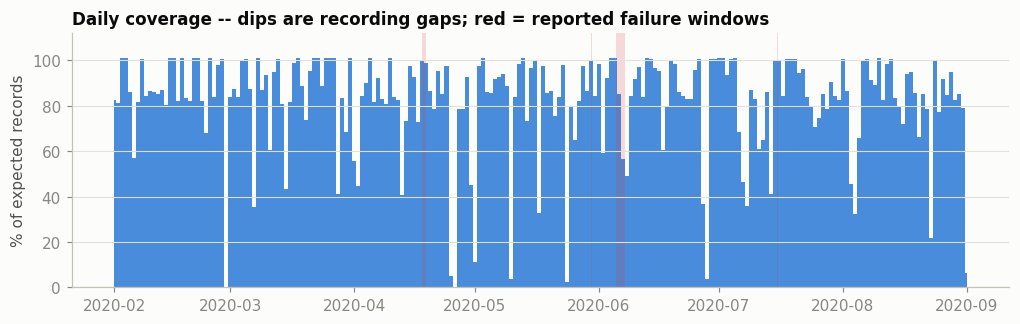

In [10]:
ts = df.set_index('timestamp')
daily = ts.resample('D').size()
expected_daily = 86400 / step

fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(daily.index, daily / expected_daily * 100,
                step='mid', color=BLUE, alpha=0.85, lw=0)
shade_failures(ax)
ax.set_ylabel('% of expected records')
ax.set_ylim(0, 112)
ax.set_title('Daily coverage -- dips are recording gaps; red = reported failure windows')
ax.grid(axis='x', visible=False)
plt.show()

### 2.1 · What the gaps are

The gaps fall into three groups. The 225 short dropouts under 3 h add up to only 135 h. The 91 gaps
of 3–12 h hold nearly half the missing time (435 h), and 76 of them start between 19:00 and
03:00 UTC; their end times cluster at 04:20–05:05 (27 of the 76), when service starts. That is the
train parked overnight. The 79 days with 75–90 % coverage lose a median of 4.0 h to gaps, so a
coverage dip is usually one night stop, not scattered loss. The 15 gaps of 12 h or more (340 h
together) are the real outages, and the survival model should censor at them rather than at every
overnight stop.

The clock is fixed UTC. Portugal moved to summer time at 01:00 UTC on 2020-03-29, and the file
records straight through that hour at the normal rate, with no jump and no hole.

In [11]:
# Gap taxonomy: overnight stops vs. outages (`big` = gaps longer than 5x the step).
gap_h = big.delta_s / 3600
short_, mid, long_ = big[gap_h < 3], big[(gap_h >= 3) & (gap_h < 12)], big[gap_h >= 12]
print(pd.DataFrame({'gaps': [len(short_), len(mid), len(long_)],
                    'hours missing': [x.delta_s.sum() / 3600 for x in (short_, mid, long_)]},
                   index=['under 3 h', '3 to 12 h', '12 h or more']).round(1))

night = mid.gap_start.dt.hour.isin([19, 20, 21, 22, 23, 0, 1, 2])
over_by_6 = mid.gap_end.dt.hour < 6
end_clock = mid.gap_end[night].dt.strftime('%H:%M')
print(f'\n3-12 h gaps starting 19:00-03:00 UTC: {night.sum()} of {len(mid)}; '
      f'over by 06:00: {(night & over_by_6).sum()}; '
      f'ending 04:20-05:05: {end_clock.between("04:20", "05:05").sum()}')
print('their end hour (UTC): ' + ', '.join(f'{h}h {n}' for h, n in
                                          end_clock.str[:2].value_counts().sort_index().items()))

# How much of a 75-90 % coverage day is gap time?
cov = daily / expected_daily
dip_days = cov[(cov >= 0.75) & (cov < 0.90)].index
gap_hours = [(big.gap_end.clip(upper=d + pd.Timedelta(days=1))
              - big.gap_start.clip(lower=d)).dt.total_seconds().clip(lower=0).sum() / 3600
             for d in dip_days]
print(f'{len(dip_days)} days with 75-90 % coverage; median gap time on those days: '
      f'{np.median(gap_hours):.1f} h')

# Timezone: Portugal moved to summer time at 2020-03-29 01:00 UTC.
print('\nRows per half hour across the DST change (UTC):')
print(ts.loc['2020-03-28 23:30':'2020-03-29 02:59:59'].resample('30min').size().to_string())

              gaps  hours missing
under 3 h      225          134.8
3 to 12 h       91          435.1
12 h or more    15          339.6

3-12 h gaps starting 19:00-03:00 UTC: 76 of 91; over by 06:00: 57; ending 04:20-05:05: 27
their end hour (UTC): 00h 12, 01h 8, 02h 3, 03h 2, 04h 26, 05h 6, 06h 2, 07h 3, 08h 1, 10h 1, 22h 4, 23h 8
79 days with 75-90 % coverage; median gap time on those days: 4.0 h

Rows per half hour across the DST change (UTC):
timestamp
2020-03-28 23:30:00    182
2020-03-29 00:00:00    182
2020-03-29 00:30:00    181
2020-03-29 01:00:00    182
2020-03-29 01:30:00    181
2020-03-29 02:00:00    182
2020-03-29 02:30:00    182
Freq: 30min


### 2.2 · Logger freezes

The 12 s and 13 s steps in the delta table are not jitter. They come in long runs during which all
seven analog channels repeat the same value exactly while COMP keeps toggling: the logger kept
writing rows, but the analog inputs had stopped updating. We call a run a **freeze** when every
analog channel is unchanged from row to row, every step is 15 s or less, and the run lasts at
least 30 minutes. That rule finds ten runs in eight episodes — 169.8 h, 3.3 % of all rows — and
they hold 99.5 % of the 11–13 s steps in the file.

Freezes are dangerous, not just noisy. The Jun 22–25 pair holds a *loaded* snapshot (TP2 8.39 bar,
5.58 A) for 62 h, which looks exactly like the failure signature. And the profile's 30 s bridge
rule would let 12 s frozen data straight through resampling. So freezes are masked explicitly,
before any feature is computed, and excluded from training, scoring and evaluation. In operation a
freeze is an NE 107 *function check* on the data, not an asset alarm.

In [12]:
def freeze_runs(df, analog, min_minutes=30, max_step_s=15):
    # Runs where every analog channel repeats exactly and every step is <= max_step_s.
    step = df.timestamp.diff().dt.total_seconds()
    same = (df[analog].diff().abs().sum(axis=1) == 0) & (step <= max_step_s)
    run = (same != same.shift()).cumsum()
    runs = df[same].groupby(run[same]).timestamp.agg(['first', 'last', 'size'])
    runs['hours'] = (runs['last'] - runs['first']).dt.total_seconds() / 3600
    return runs[runs.hours >= min_minutes / 60].reset_index(drop=True)

freezes = freeze_runs(df, ANALOG)
frozen = np.zeros(len(df), dtype=bool)
for first, last in zip(freezes['first'], freezes['last']):
    frozen |= ((df.timestamp >= first) & (df.timestamp <= last)).to_numpy()
df['frozen'] = frozen
ts['frozen'] = frozen          # ts has the same row order as df
tsu = ts[~ts.frozen]           # unfrozen rows: the analyses below use these

def shade_freezes(ax):
    # Grey wash over the logger freezes.
    for first, last in zip(freezes['first'], freezes['last']):
        ax.axvspan(first, last, color=MUTED, alpha=0.2, lw=0)

steps = df.timestamp.diff().dt.total_seconds()
odd = steps.between(11, 13)
print(f'{len(freezes)} freeze runs, {freezes.hours.sum():.1f} h, {frozen.sum():,} rows '
      f'({frozen.mean():.1%} of the file)')
print(f'11-13 s steps inside freezes: {(odd & frozen).sum():,} of {odd.sum():,} '
      f'({(odd & frozen).sum() / odd.sum():.1%})')
outside = steps[~frozen].value_counts(normalize=True)
print('steps outside freezes: '
      + ', '.join(f'{s:g} s {p:.1%}' for s, p in outside.head(2).items())
      + f', anything else {1 - outside.head(2).sum():.2%}')
one_s = pd.Timedelta(seconds=1)
matches = len(freezes) == len(FREEZE_MASKS) and all(
    abs(f - s) <= one_s and abs(l - e) <= one_s
    for f, l, (s, e) in zip(freezes['first'], freezes['last'], FREEZE_MASKS))
print('matches the planned events.yaml v0.2 masks:', 'yes' if matches else 'NO -- update FREEZE_MASKS')

held = ts.loc[freezes['first'], ['TP2', 'Motor_current']].to_numpy()
pd.DataFrame({
    'start': freezes['first'],
    'end': freezes['last'],
    'hours': freezes.hours.round(1),
    'median step (s)': [steps[(df.timestamp > f) & (df.timestamp <= l)].median()
                        for f, l in zip(freezes['first'], freezes['last'])],
    'state held': [('off' if a < 1 else 'loaded' if a > 4.5 else 'off-load')
                   + f' (TP2 {p:.2f} bar, {a:.2f} A)' for p, a in held],
})

10 freeze runs, 169.8 h, 50,677 rows (3.3% of the file)
11-13 s steps inside freezes: 50,536 of 50,780 (99.5%)
steps outside freezes: 10 s 91.2%, 9 s 8.7%, anything else 0.04%
matches the planned events.yaml v0.2 masks: yes


,start,end,hours,median step (s),state held
0,2020-04-13 18:29:20,2020-04-13 19:27:16,1.0,12.0,"off-load (TP2 0.00 bar, 4.10 A)"
1,2020-04-17 09:20:43,2020-04-18 00:18:07,15.0,12.0,"off (TP2 -0.02 bar, 0.04 A)"
2,2020-04-20 04:49:17,2020-04-21 01:16:52,20.5,12.0,"off-load (TP2 -0.01 bar, 3.92 A)"
3,2020-05-26 09:19:36,2020-05-27 13:43:45,28.4,12.0,"off (TP2 -0.01 bar, 0.04 A)"
4,2020-05-27 13:54:04,2020-05-28 03:16:28,13.4,12.0,"off (TP2 -0.01 bar, 0.04 A)"
5,2020-06-12 02:01:56,2020-06-12 17:00:07,15.0,12.0,"off (TP2 -0.02 bar, 0.04 A)"
6,2020-06-22 15:06:21,2020-06-23 02:56:00,11.8,12.0,"loaded (TP2 8.39 bar, 5.58 A)"
7,2020-06-23 02:56:35,2020-06-25 05:08:35,50.2,12.0,"loaded (TP2 8.39 bar, 5.58 A)"
8,2020-07-21 13:45:12,2020-07-21 22:03:16,8.3,12.0,"off (TP2 -0.01 bar, 0.04 A)"
9,2020-07-22 06:43:44,2020-07-22 13:04:24,6.3,12.0,"off-load (TP2 -0.02 bar, 3.74 A)"


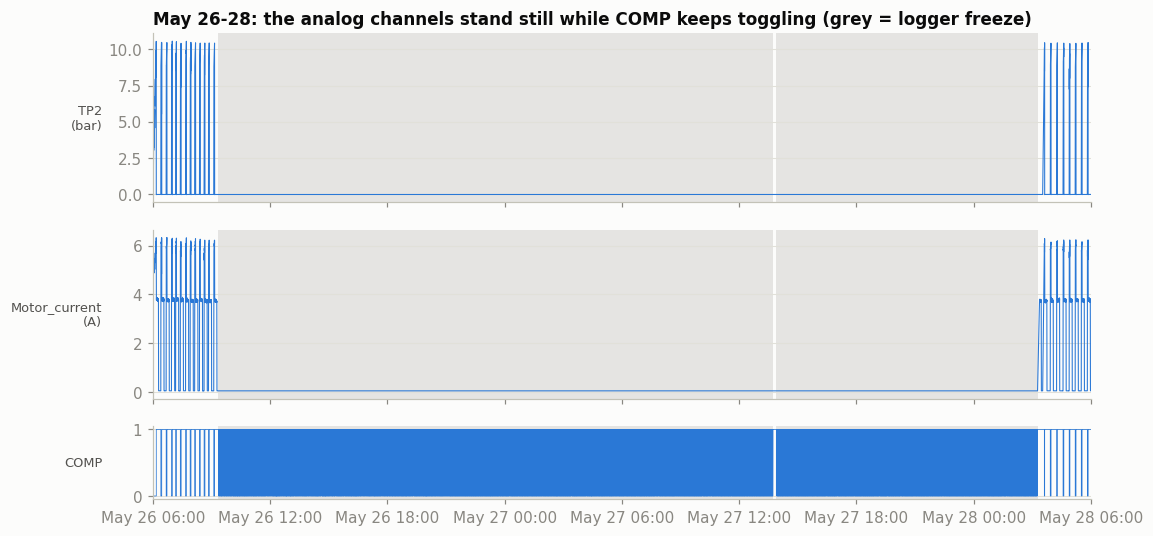

In [13]:
# One freeze episode up close: May 26-28, two runs back to back.
z0, z1 = pd.Timestamp('2020-05-26 06:00'), pd.Timestamp('2020-05-28 06:00')
seg = ts.loc[z0:z1]
fig, axes = plt.subplots(3, 1, figsize=(11, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 3, 1.3]})
axes[0].plot(seg.index, seg.TP2, color=BLUE, lw=0.7)
axes[1].plot(seg.index, seg.Motor_current, color=BLUE, lw=0.7)
axes[2].step(seg.index, seg.COMP, where='post', color=BLUE, lw=0.5)
axes[2].set_yticks([0, 1])
for ax, label in zip(axes, ['TP2\n(bar)', 'Motor_current\n(A)', 'COMP']):
    ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=8.5)
    shade_freezes(ax)
    ax.set_xlim(z0, z1)
    ax.grid(axis='x', visible=False)
axes[0].set_title('May 26-28: the analog channels stand still while COMP keeps toggling '
                  '(grey = logger freeze)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
fig.align_ylabels(axes)
plt.show()

## 3 · Analog signals

Distributions first, then the whole period at a glance, then one hour of raw signal, and finally
the correlation structure. Four things stand out on the full data:

- Normal operation is **short load bursts** — the compressor is under load only ~16 % of the time
  (the hour of raw signal below shows a single two-minute charge in an hour). That is what makes
  TP2 and Motor_current strongly bimodal, plain thresholds useless, and reconstruction-based
  detection attractive.
- **February is a different operating regime**: light duty throughout, LPS silent, and the shift
  happens across the Feb 28 – Mar 1 gap. The detector should not be fit on February alone, and
  train/validation splits should respect the regime change.
- **DV_pressure changes regime at the Jun 8 repair** (Section 3.1), a second boundary the splits
  have to respect.
- **TP3 and Reservoirs are duplicates** (r = 1.00): one of them suffices as a detector input. Their
  divergence is a free sensor-health check, but it never fires in 2020 (Section 3.2). TP2 and H1
  mirror each other (r = −0.96), so H1 adds little linear information — but its failure behavior
  (Section 5) is the crispest signature in the dataset.

The flat stretches in the seven-month chart are logger freezes (grey), not the compressor idling.

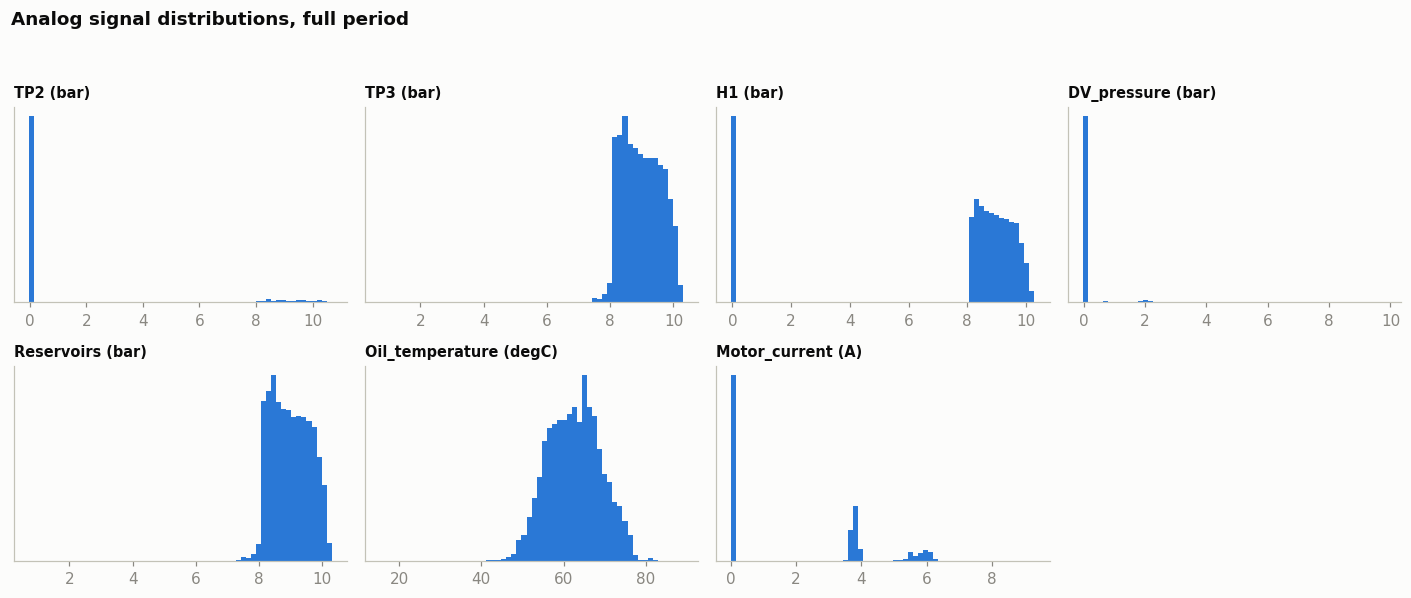

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for ax, c in zip(axes.flat, ANALOG):
    ax.hist(df[c].dropna(), bins=60, color=BLUE, lw=0)
    ax.set_title(f'{c} ({UNITS[c]})', fontsize=9.5)
    ax.set_yticks([])
    ax.grid(axis='x', visible=False)
axes.flat[-1].axis('off')
fig.suptitle('Analog signal distributions, full period', x=0.01, ha='left',
             fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

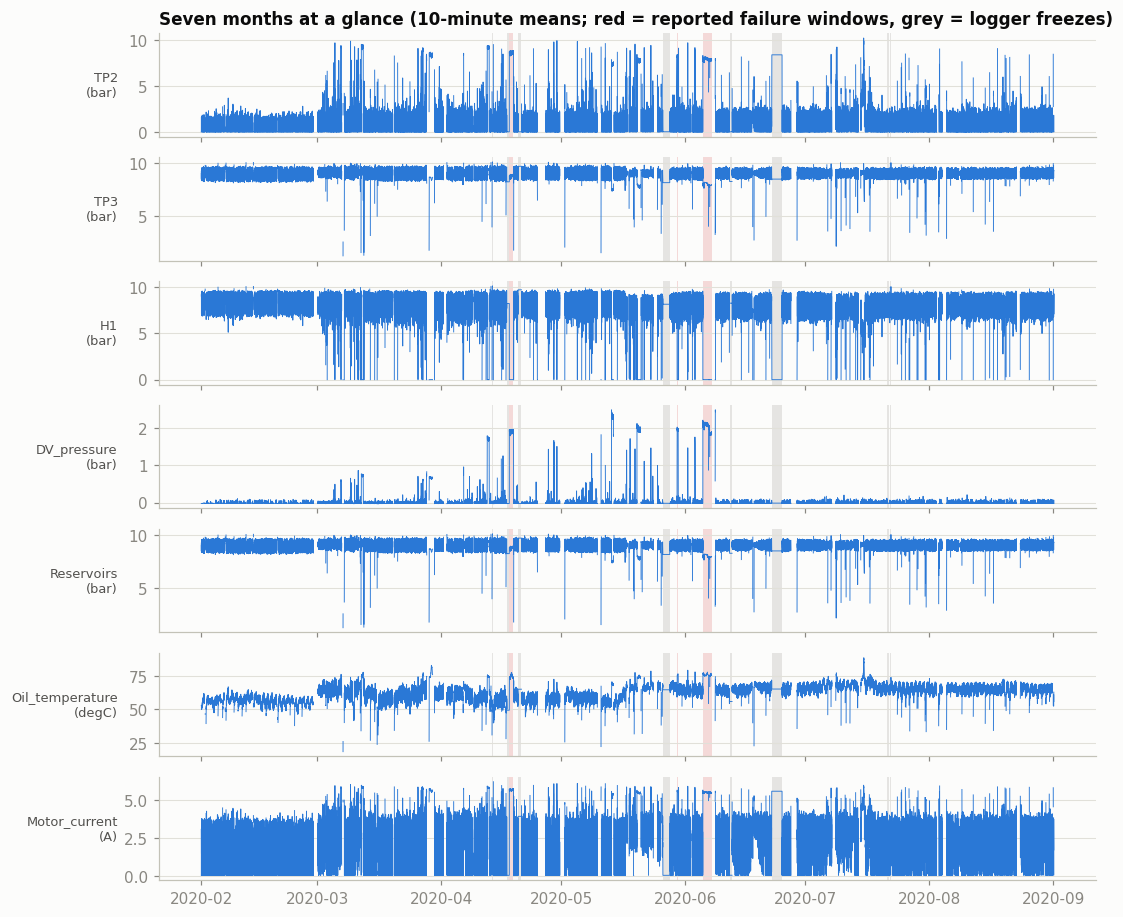

In [15]:
res = ts[ANALOG].resample('10min').mean()
fig, axes = plt.subplots(len(ANALOG), 1, figsize=(11, 10), sharex=True)
for ax, c in zip(axes, ANALOG):
    ax.plot(res.index, res[c], color=BLUE, lw=0.6)
    shade_failures(ax)
    shade_freezes(ax)
    ax.set_ylabel(f'{c}\n({UNITS[c]})', rotation=0, ha='right',
                  va='center', fontsize=8.5)
    ax.grid(axis='x', visible=False)
axes[0].set_title('Seven months at a glance (10-minute means; red = reported failure windows, '
                  'grey = logger freezes)')
fig.align_ylabels(axes)
plt.show()

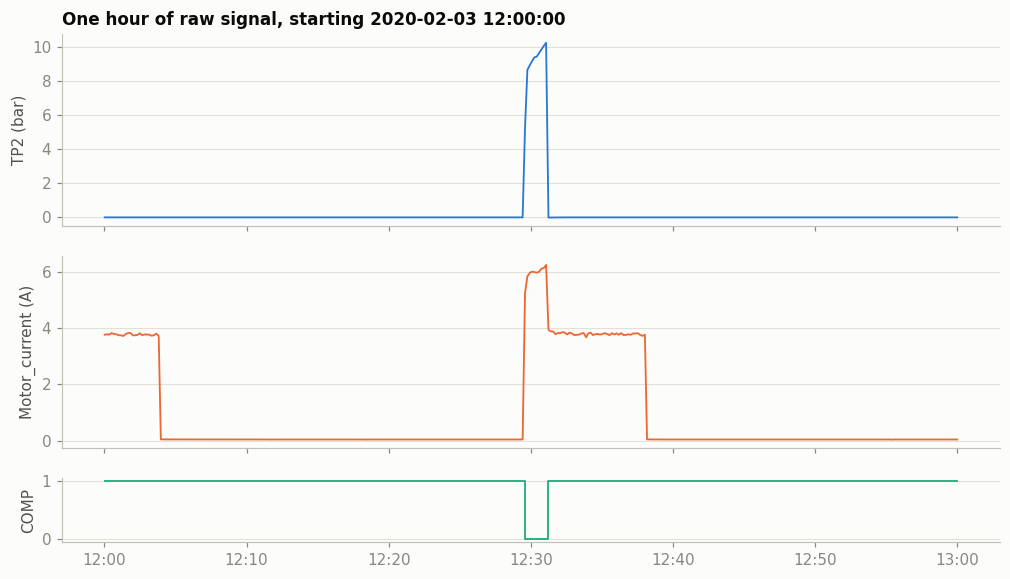

In [16]:
# One hour of raw signal: pick an early hour with near-complete coverage.
hourly = ts.resample('h').size()
full_hours = hourly[hourly >= 0.95 * 3600 / step]
zoom_start = (full_hours.index[min(48, len(full_hours) - 1)]
              if len(full_hours) else ts.index[0])
zoom = ts.loc[zoom_start: zoom_start + pd.Timedelta(hours=1)]

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 3, 1]})
axes[0].plot(zoom.index, zoom.TP2, color=BLUE, lw=1.2)
axes[0].set_ylabel('TP2 (bar)')
axes[1].plot(zoom.index, zoom.Motor_current, color=ORANGE, lw=1.2)
axes[1].set_ylabel('Motor_current (A)')
axes[2].step(zoom.index, zoom.COMP, where='post', color=AQUA, lw=1.2)
axes[2].set_ylabel('COMP')
axes[2].set_yticks([0, 1])
axes[0].set_title(f'One hour of raw signal, starting {zoom_start}')
for ax in axes:
    ax.grid(axis='x', visible=False)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.show()

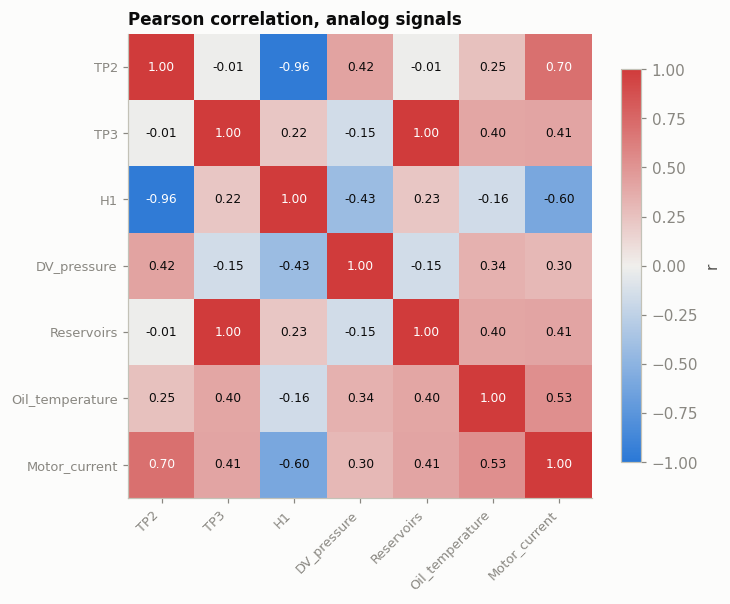

In [17]:
corr = ts[ANALOG].corr()
n = len(ANALOG)
fig, ax = plt.subplots(figsize=(6.8, 5.8))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(n), ANALOG, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(n), ANALOG, fontsize=8.5)
for i in range(n):
    for j in range(n):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='#0b0b0b' if abs(v) < 0.65 else '#ffffff')
ax.set_title('Pearson correlation, analog signals')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label='r')
plt.show()

### 3.1 · DV_pressure goes flat after the Jun 8 repair

DV_pressure carries signal until the F3 repair on Jun 8 at 16:00, then goes flat: its 99th
percentile drops from 2.21 bar to −0.01 bar, and the share of samples above 0.5 bar from 7.3 % to
0.2 %. F1–F3 all fall before the change and F4 after it, so the channel has two different
"normals". A fit weighted toward either side will score the other side's ordinary load cycles as
anomalies. We drop DV_pressure from the detector inputs (or, if the healthy fit suffers, split
the fit at Jun 8 16:00) and add the boundary to `regimes` in `events.yaml`.

                            before Jun 8 16:00  after
99th percentile (bar)                     2.21  -0.01
% of samples above 0.5 bar                7.30   0.20


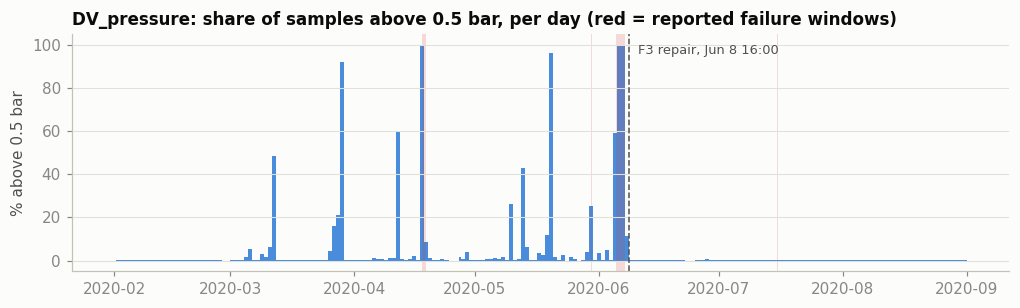

In [18]:
split = REGIME_SPLITS[1]
before = tsu.DV_pressure[tsu.index < split]
after = tsu.DV_pressure[tsu.index >= split]
print(pd.DataFrame({'before Jun 8 16:00': [before.quantile(0.99), (before > 0.5).mean() * 100],
                    'after': [after.quantile(0.99), (after > 0.5).mean() * 100]},
                   index=['99th percentile (bar)', '% of samples above 0.5 bar']).round(2))

daily_dv = (tsu.DV_pressure > 0.5).resample('D').mean() * 100
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.fill_between(daily_dv.index, daily_dv, step='mid', color=BLUE, alpha=0.85, lw=0)
shade_failures(ax)
ax.axvline(split, color=INK2, lw=1, ls='--')
ax.annotate('F3 repair, Jun 8 16:00', (split, 0.96), xycoords=('data', 'axes fraction'),
            xytext=(6, 0), textcoords='offset points', color=INK2, fontsize=8.5, va='top')
ax.set_ylabel('% above 0.5 bar')
ax.set_title('DV_pressure: share of samples above 0.5 bar, per day (red = reported failure windows)')
ax.grid(axis='x', visible=False)
plt.show()

### 3.2 · TP3 vs Reservoirs: the divergence check never fires

The two channels agree to within 0.010 bar at the 99.9th percentile. Only three rows in seven
months differ by more than 0.1 bar, and never two in a row, so the profile's rule (more than
0.1 bar, sustained over 10 minutes) never fires on 2020 data. The check stays, since it costs
nothing, but Journey C will need injected sensor faults to exercise it.

In [19]:
div = (ts.TP3 - ts.Reservoirs).abs()
wide = div > 0.1
print(f'|TP3 - Reservoirs|: 99.9th percentile {div.quantile(0.999):.3f} bar; '
      f'rows above 0.1 bar: {wide.sum()}; two in a row: '
      f'{(wide & wide.shift(fill_value=False)).sum()}')
ts.loc[wide, ['TP3', 'Reservoirs']]

|TP3 - Reservoirs|: 99.9th percentile 0.010 bar; rows above 0.1 bar: 3; two in a row: 0


,TP3,Reservoirs
timestamp,,
2020-03-12 11:59:34,8.296,8.466
2020-04-06 10:02:19,4.728,4.910
2020-05-16 23:25:44,6.606,6.768


## 4 · Digital signals

Duty cycles over the whole period first, then the cycling story. Three findings:

- **The digital channels mostly mean what the paper says.** Section 4.1 reads each one against the
  analog signals. COMP, DV_eletric, MPG and LPS behave as described, and the odd duty cycles have
  plain explanations: Towers only switches while the compressor is loaded, Pressure_switch's
  eventful state is 0, and Oil_level and Caudal_impulses drop to 0 almost only within single
  months (August and March) and never at a failure.
- **Cycling rate is not a precursor.** The raw count spikes to 380–1,400 cycles a day on seven days
  (Apr 17, Apr 20, May 26–27, Jun 12, Jul 21–22), and the first run read that as warning before F1
  and F2. All seven days sit inside logger freezes (Section 2.2), where COMP chatters while the
  analog channels stand still. With freezes masked, those days show 0–55 cycles against a campaign
  median of 55 and a 95th percentile of 83, and none of the four failures is preceded by elevated
  cycling (table below). The lead-time evidence we do have is in load share (Section 5.2).
- **Not every anomaly is labeled.** Six continuous-load episodes with the failure signature have
  no report (Section 5.1), and neither do the heavy LPS days (Apr 25 — followed by a two-day gap —
  early May, Jul 1). Under the current labels these would score as false alarms, so they are
  uncertain periods in `events.yaml` v0.2, and FAR is reported with and without them.

One caveat stands: at a 10 s sampling interval, cycles shorter than a couple of samples alias,
so cycle counts are a lower bound.

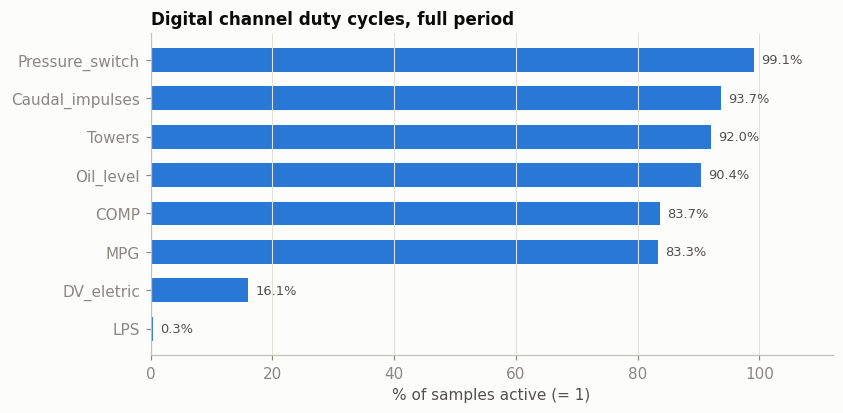

In [20]:
duty = ts[DIGITAL].mean().sort_values() * 100
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(duty.index, duty, color=BLUE, height=0.62)
for y, v in enumerate(duty):
    ax.text(v + 1.2, y, f'{v:.1f}%', va='center', fontsize=8.5, color=INK2)
ax.set_xlabel('% of samples active (= 1)')
ax.set_xlim(0, 112)
ax.set_title('Digital channel duty cycles, full period')
ax.grid(axis='y', visible=False)
plt.show()

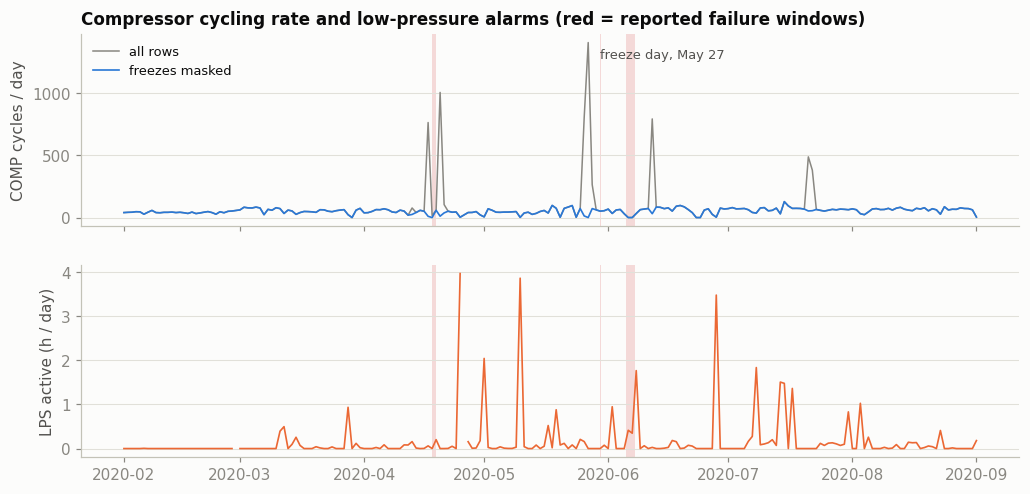

In [21]:
flip = ts.COMP.diff().abs() == 1
both_live = ~ts.frozen & ~ts.frozen.shift(fill_value=False)
has_rows = ts.COMP.resample('D').size() > 0
comp_raw = (flip.resample('D').sum() / 2)[has_rows]
comp_cycles = ((flip & both_live).resample('D').sum() / 2)[has_rows]
lps_hours = ts.LPS.resample('D').mean() * 24

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(comp_raw.index, comp_raw, color=MUTED, lw=1.0, label='all rows')
axes[0].plot(comp_cycles.index, comp_cycles, color=BLUE, lw=1.1, label='freezes masked')
peak = comp_raw.idxmax()
axes[0].annotate(f'freeze day, {peak:%b %d}', (peak, comp_raw.max()), xytext=(8, -4),
                 textcoords='offset points', color=INK2, fontsize=8.5, va='top')
axes[0].legend(loc='upper left', frameon=False, fontsize=8.5)
axes[0].set_ylabel('COMP cycles / day')
axes[0].set_title('Compressor cycling rate and low-pressure alarms '
                  '(red = reported failure windows)')
axes[1].plot(lps_hours.index, lps_hours, color=ORANGE, lw=1.1)
axes[1].set_ylabel('LPS active (h / day)')
for ax in axes:
    shade_failures(ax)
    ax.grid(axis='x', visible=False)
plt.show()

In [22]:
spikes = comp_raw[comp_raw >= 300]
print('Days with 300 or more raw cycles, and the same days with freezes masked:')
print(pd.DataFrame({'all rows': spikes, 'freezes masked': comp_cycles[spikes.index]})
        .astype(int).rename(index=lambda d: d.strftime('%b %d')).rename_axis(None).to_string())
print(f'\nFreezes masked, whole campaign: median {comp_cycles.median():.0f} cycles/day, '
      f'95th percentile {comp_cycles.quantile(0.95):.0f}')
print('\nCycles on the three days before each reported failure (freezes masked):')
pre_days = {name: [comp_cycles.get(s.normalize() - pd.Timedelta(days=k)) for k in (3, 2, 1)]
            for s, e, name in FAILURE_WINDOWS}
pd.DataFrame(pre_days, index=['3 days before', '2 days before', 'day before']).T.astype(int)

Days with 300 or more raw cycles, and the same days with freezes masked:
        all rows  freezes masked
Apr 17       764              10
Apr 20      1006              11
May 26       806              13
May 27      1407               0
Jun 12       793              31
Jul 21       488              53
Jul 22       381              55

Freezes masked, whole campaign: median 55 cycles/day, 95th percentile 83

Cycles on the three days before each reported failure (freezes masked):


,3 days before,2 days before,day before
Air leak 1,58,51,10
Air leak 2,13,0,72
Air leak 3,33,61,65
Air leak 4,58,76,30


### 4.1 · Digital channels by operating state

Four channels had duty cycles that were hard to square with the paper, so here every channel is
read against the operating state from the analog side — *loaded* when Motor_current is above
4.5 A — with freezes masked.

- **COMP, MPG and DV_eletric** are consistent with the paper: COMP and MPG sit at 0 while loading,
  and 98.7 % of DV_eletric = 1 samples have the motor loaded.
- **LPS** fires when the reservoirs fall below 7 bar: 84 % of LPS = 1 samples have Reservoirs below
  7 bar, and 96 % of samples below 7 bar have LPS = 1.
- **Towers** averages 0.50 under load and 1.00 otherwise. The towers alternate only while the
  compressor loads, which is why the channel reads 92 % active.
- **Pressure_switch** is 0 in the rare, eventful state (about 22 transitions a day), and mostly
  under load: 1.0 % of loaded samples outside the failure windows, 0.5 % of loaded samples inside
  them. The zeros are a load effect, not a failure signal.
- **Oil_level** reads 0 almost only in August (most of Aug 5–14 and Aug 18–24, plus Jul 30) and
  never inside a failure window; **Caudal_impulses** reads 0 only in March (34 % of March
  samples). Neither carries failure information in 2020. Both go to the digital polarity audit,
  not to the detector.

In [23]:
loaded = tsu.Motor_current > 4.5
days_live = tsu.COMP.resample('D').size() > 0
by_state = pd.DataFrame({
    '% at 1, loaded': tsu.loc[loaded, DIGITAL].mean() * 100,
    '% at 1, not loaded': tsu.loc[~loaded, DIGITAL].mean() * 100,
    'transitions / day (median)': [
        (tsu[c].diff().abs() == 1).resample('D').sum()[days_live].median() for c in DIGITAL],
}).round(1)
print(f'DV_eletric = 1 samples with the motor loaded (> 4.5 A): '
      f'{loaded[tsu.DV_eletric == 1].mean():.1%}')
res_low = tsu.Reservoirs < 7
print(f'LPS = 1 samples with Reservoirs below 7 bar: {res_low[tsu.LPS == 1].mean():.0%}; '
      f'samples below 7 bar with LPS = 1: {(tsu.LPS[res_low] == 1).mean():.0%}')
by_state

DV_eletric = 1 samples with the motor loaded (> 4.5 A): 98.7%
LPS = 1 samples with Reservoirs below 7 bar: 84%; samples below 7 bar with LPS = 1: 96%


,"% at 1, loaded","% at 1, not loaded",transitions / day (median)
COMP,0.5,99.8,110.0
DV_eletric,99.5,0.2,110.0
Towers,50.1,99.9,188.0
MPG,0.4,99.8,110.0
LPS,1.9,0.1,0.0
Pressure_switch,99.1,99.9,22.0
Oil_level,92.5,91.0,0.0
Caudal_impulses,94.4,94.7,0.0


In [24]:
in_fail = np.zeros(len(tsu), dtype=bool)
for s, e, _ in FAILURE_WINDOWS:
    in_fail |= (tsu.index >= s) & (tsu.index <= e)
ld = loaded.to_numpy()
ps0 = (tsu.Pressure_switch == 0).to_numpy()
print('Pressure_switch = 0, share of samples:')
print(f'  loaded, in failure windows {ps0[ld & in_fail].mean():.2%} | loaded, outside failures '
      f'{ps0[ld & ~in_fail].mean():.2%} | not loaded {ps0[~ld & ~in_fail].mean():.2%}')
print(f'Oil_level = 0 in failure windows: {(tsu.Oil_level.to_numpy()[in_fail] == 0).mean():.1%}; '
      f'Caudal_impulses = 0 in failure windows: '
      f'{(tsu.Caudal_impulses.to_numpy()[in_fail] == 0).mean():.1%}')
oil_days = (tsu.Oil_level == 0).resample('D').mean()
print('days with Oil_level = 0 for more than half the samples: '
      + ', '.join(oil_days[oil_days > 0.5].index.strftime('%b %d')))
print('\nShare of samples at 0, by month (%):')
((tsu[['Oil_level', 'Caudal_impulses']] == 0).resample('MS').mean() * 100).round(1) \
    .rename(index=lambda d: d.strftime('%b')).rename_axis(None).T

Pressure_switch = 0, share of samples:
  loaded, in failure windows 0.47% | loaded, outside failures 1.00% | not loaded 0.06%
Oil_level = 0 in failure windows: 0.0%; Caudal_impulses = 0 in failure windows: 0.0%
days with Oil_level = 0 for more than half the samples: Jul 30, Aug 05, Aug 06, Aug 07, Aug 08, Aug 09, Aug 10, Aug 11, Aug 12, Aug 13, Aug 14, Aug 18, Aug 19, Aug 20, Aug 21, Aug 22, Aug 23, Aug 24

Share of samples at 0, by month (%):


,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep
Oil_level,0.0,0.4,0.0,0.0,0.0,2.7,55.3,0.0
Caudal_impulses,0.0,34.2,0.0,0.0,0.0,0.0,0.0,0.0


## 5 · Failure windows

Each reported failure, plus and minus three days, on the three most diagnostic signals. The
pattern is the same in all four windows: **normal cycling stops and the unit runs continuously
under load** — TP2 pinned near 8–9 bar, Motor_current flat around 5.6 A, oil temperature
climbing to 75–90 °C (the fourth leak reaches ~89 °C, the dataset maximum), and H1 collapsed to
~0 for the whole window. Detecting a failure *while it is happening* is therefore easy; the
modeling problem worth solving is the precursor phase before it (Section 5.2).

The flat stretches just before F1 (Apr 17) and F2 (May 26–28) are logger freezes, shaded grey.
The first run read them as the compressor parked; they are missing data, masked everywhere below.

Two label caveats. The first window spans exactly 00:00–23:59 and the others are given to the half
hour, so the reports mark roughly when a leak was noticed, not when it began — window edges are
not precise timestamps, and evaluation should use guard bands around them. And because TP2 and
DV_pressure idle near zero (and H1 drops to near zero under load), percentage change against
baseline is misleading;
the comparison below uses absolute differences in each signal's own unit, with freezes masked
(they sit in the baseline weeks of F1 and F2).

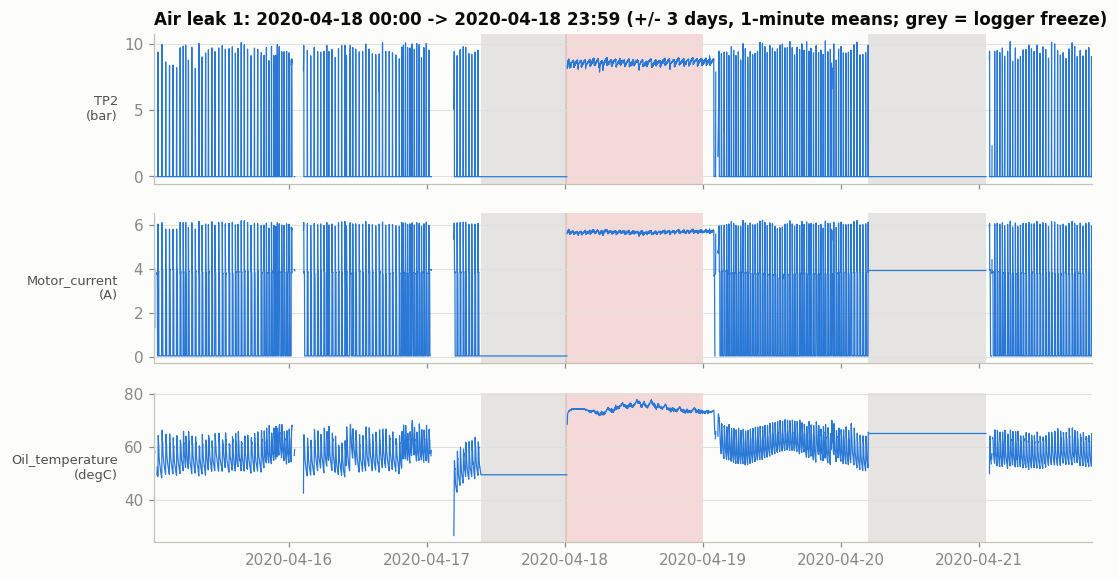

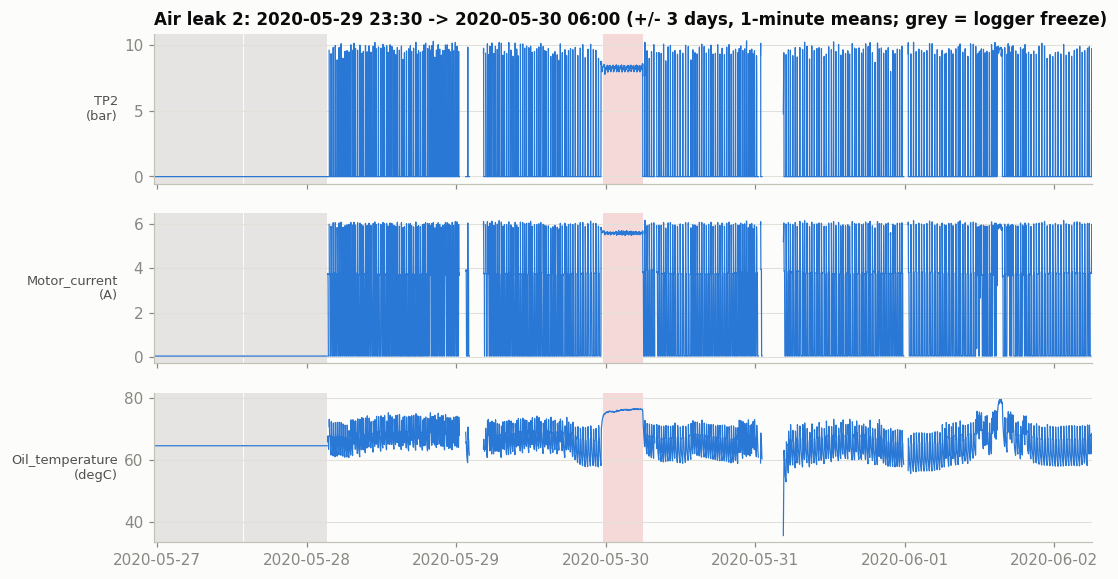

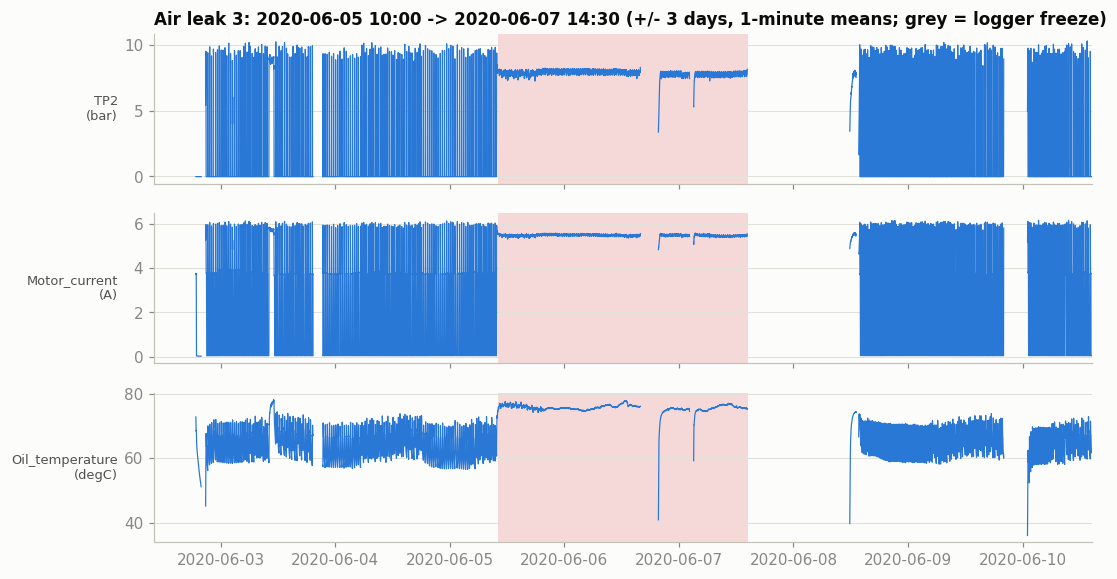

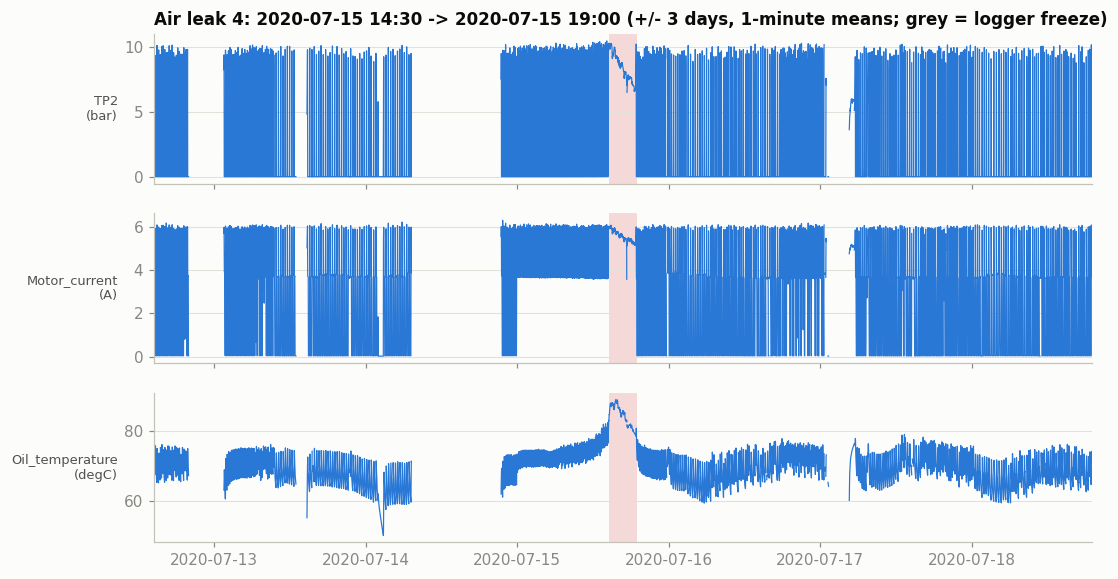

In [25]:
ZOOM_PAD = pd.Timedelta(days=3)
SIG3 = ['TP2', 'Motor_current', 'Oil_temperature']

for s, e, name in FAILURE_WINDOWS:
    seg = ts.loc[s - ZOOM_PAD: e + ZOOM_PAD, SIG3].resample('1min').mean()
    if seg.dropna(how='all').empty:
        print(f'{name}: no data within +/- 3 days of the window')
        continue
    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    for ax, c in zip(axes, SIG3):
        ax.plot(seg.index, seg[c], color=BLUE, lw=0.8)
        ax.axvspan(s, e, color=CRITICAL, alpha=0.18, lw=0)
        shade_freezes(ax)
        ax.set_xlim(seg.index[0], seg.index[-1])
        ax.set_ylabel(f'{c}\n({UNITS[c]})', rotation=0, ha='right',
                      va='center', fontsize=8.5)
        ax.grid(axis='x', visible=False)
    axes[0].set_title(f'{name}: {s:%Y-%m-%d %H:%M} -> {e:%Y-%m-%d %H:%M} '
                      f'(+/- 3 days, 1-minute means; grey = logger freeze)')
    fig.align_ylabels(axes)
    plt.show()

In [26]:
BASELINE = pd.Timedelta(days=7)
rows = {}
for s, e, name in FAILURE_WINDOWS:
    during = tsu.loc[s:e, ANALOG].mean()
    before = tsu.loc[s - BASELINE: s, ANALOG].mean()
    rows[name] = during - before
chg = pd.DataFrame(rows).loc[ANALOG].round(2)
print('Mean level during each failure window minus the preceding 7 days, freezes masked')
print('(absolute change, in each signal unit -- bar, degC, A):')
chg

Mean level during each failure window minus the preceding 7 days, freezes masked
(absolute change, in each signal unit -- bar, degC, A):


,Air leak 1,Air leak 2,Air leak 3,Air leak 4
TP2,6.98,6.70,6.47,6.48
TP3,-0.23,-0.62,-0.96,-0.80
H1,-7.35,-7.45,-7.49,-6.91
DV_pressure,1.73,1.92,1.92,-0.00
Reservoirs,-0.23,-0.62,-0.96,-0.80
Oil_temperature,16.00,8.89,10.49,15.28
Motor_current,3.76,3.05,3.43,2.70


### 5.1 · Continuous load with no report

The failure signature — hours of uninterrupted load — also appears six times without a report. We
flag a *continuous-load episode* when every minute for at least 4 h holds a loaded sample (TP2
above 6 bar and Motor_current above 4.5 A, freezes masked). The rule finds F1, F2 and F3 and six
more episodes of 4–22 h. F4 is missing only because a one-minute recording gap at 17:23 splits its
run into two pieces shorter than 4 h.

What separates them is pressure. All four reported leaks pull TP3 down against the week before
(−0.2 to −1.0 bar): the compressor runs flat out and still loses ground. Three unreported episodes
do the same (Mar 28–29, May 13–14, May 19–20) and read as leaks nobody wrote up; the May pair, 16
and 10 days before F2, may be its early stage. The other three hold or raise pressure (Mar 12,
Mar 27, Apr 12), which fits heavy air demand rather than a leak.

All six are uncertain periods in `events.yaml` v0.2, tagged `probable_leak` or `load_held`. They
are excluded from healthy data, alarms inside them are audited rather than counted as false, and
FAR is reported with and without them. Before any lead time is quoted, the team has to decide
whether alarms on May 13–14 and May 19–20 count toward F2.

After F3, data resume on Jun 8 at 11:48, four hours before the 16:00 repair, with another 1.1 h
of continuous load. That stretch is the grey period in `events.yaml` v0.2: neither healthy nor a
labeled failure.

In [27]:
# Continuous-load episodes: every minute for >= 4 h holds a loaded sample.
loaded_row = (tsu.TP2 > 6) & (tsu.Motor_current > 4.5)
loaded_min = loaded_row.astype(int).resample('1min').max().fillna(0).astype(bool)

def load_runs(min_hours):
    run_id = (loaded_min != loaded_min.shift()).cumsum()[loaded_min]
    spans = loaded_min.index[loaded_min].to_series().groupby(run_id).agg(['first', 'last'])
    spans = spans[spans['last'] - spans['first'] >= pd.Timedelta(hours=min_hours)]
    hits = loaded_row.index[loaded_row]
    out = []
    for a, b in zip(spans['first'], spans['last']):
        inside = hits[(hits >= a) & (hits < b + pd.Timedelta(minutes=1))]
        out.append((inside[0], inside[-1]))
    return out

def report_for(a, b):
    return next((name for s, e, name in FAILURE_WINDOWS if a <= e and b >= s), '-')

rows = []
for a, b in load_runs(4):
    base = tsu.TP3.loc[a - pd.Timedelta(days=7): a].mean()
    rows.append({'start': a, 'end': b, 'hours': round((b - a).total_seconds() / 3600, 1),
                 'report': report_for(a, b),
                 'dTP3 vs prior 7 d (bar)': round(tsu.TP3.loc[a:b].mean() - base, 2),
                 'TP3 min (bar)': round(tsu.TP3.loc[a:b].min(), 2),
                 'oil max (degC)': round(tsu.Oil_temperature.loc[a:b].max(), 1)})
episodes = pd.DataFrame(rows)
unrep = episodes[episodes.report == '-'].reset_index(drop=True)

yaml_eps = [(s, e, tag) for s, e, tag in UNCERTAIN if tag != 'lps_heavy']
one_min = pd.Timedelta(minutes=1)
matches = len(unrep) == len(yaml_eps) and all(
    abs(a - s) < one_min and abs(b - e) < one_min
    and (tag == 'probable_leak') == (d < 0)
    for a, b, d, (s, e, tag) in zip(unrep.start, unrep.end,
                                    unrep['dTP3 vs prior 7 d (bar)'], yaml_eps))
print(f'{len(episodes)} continuous-load runs of 4 h or more; {len(unrep)} overlap no report; '
      f'{int((unrep["dTP3 vs prior 7 d (bar)"] < 0).sum())} of those with falling TP3')
print('unreported episodes match the planned events.yaml v0.2 entries (spans and tags):',
      'yes' if matches else 'NO')
s4, e4, _ = FAILURE_WINDOWS[3]
pieces = [(a, b) for a, b in load_runs(0.5) if a <= e4 and b >= s4]
no_data = tsu.TP2.loc[s4:e4].resample('1min').size()
print('F4: continuous-load pieces ' + ', '.join(f'{a:%H:%M}-{b:%H:%M}' for a, b in pieces)
      + '; minutes with no data inside the window: '
      + (', '.join(no_data.index[no_data == 0].strftime('%H:%M')) or 'none'))
grey_runs = [(a, b) for a, b in load_runs(1) if GREY[0][0] <= a <= GREY[0][1]]
for a, b in grey_runs:
    print(f'grey period, before the F3 repair: continuous load {a:%H:%M}-{b:%H:%M} '
          f'({(b - a).total_seconds() / 3600:.1f} h)')
episodes

11 continuous-load runs of 4 h or more; 6 overlap no report; 3 of those with falling TP3
unreported episodes match the planned events.yaml v0.2 entries (spans and tags): yes
F4: continuous-load pieces 14:25-17:22, 17:24-18:52; minutes with no data inside the window: 17:23
grey period, before the F3 repair: continuous load 12:01-13:07 (1.1 h)


,start,end,hours,report,dTP3 vs prior 7 d (bar),TP3 min (bar),oil max (degC)
0,2020-03-12 00:16:16,2020-03-12 11:49:50,11.6,-,0.37,7.95,78.0
1,2020-03-27 07:12:20,2020-03-27 11:38:11,4.4,-,0.22,8.15,77.8
2,2020-03-28 23:21:14,2020-03-29 19:49:14,20.5,-,-0.43,5.73,83.1
3,2020-04-12 11:50:31,2020-04-12 23:36:00,11.8,-,0.43,8.04,76.3
4,2020-04-18 00:23:59,2020-04-19 01:55:36,25.5,Air leak 1,-0.22,8.04,78.2
5,2020-05-13 13:45:04,2020-05-14 00:56:48,11.2,-,-1.41,7.08,71.1
6,2020-05-19 22:20:28,2020-05-20 19:48:20,21.5,-,-0.99,7.46,76.1
7,2020-05-29 23:15:06,2020-05-30 05:56:46,6.7,Air leak 2,-0.63,8.06,76.6
8,2020-06-05 09:48:40,2020-06-06 15:55:17,30.1,Air leak 3,-0.87,7.29,78.0
9,2020-06-06 19:51:45,2020-06-07 02:13:24,6.4,Air leak 3,-0.94,5.72,75.8


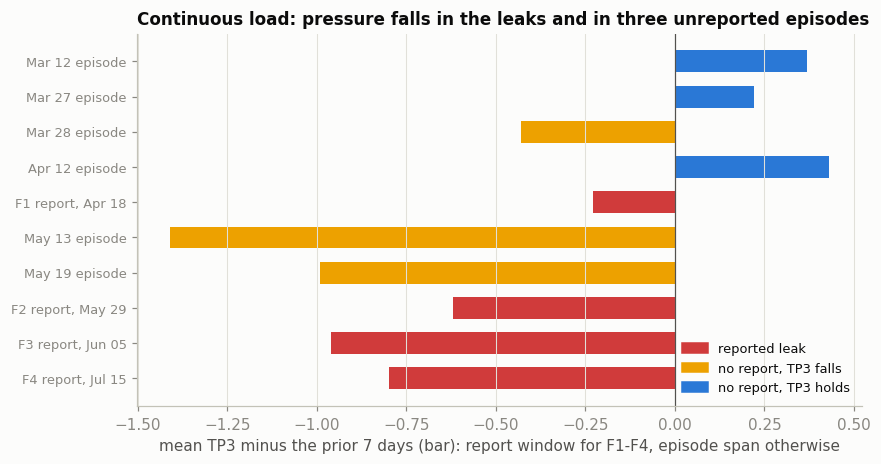

In [28]:
bars = [(s, f'F{i} report, {s:%b %d}', chg.loc['TP3', name], 'reported leak')
        for i, (s, e, name) in enumerate(FAILURE_WINDOWS, start=1)]
for _, r in unrep.iterrows():
    d = r['dTP3 vs prior 7 d (bar)']
    bars.append((r['start'], f"{r['start']:%b %d} episode", d,
                 'no report, TP3 falls' if d < 0 else 'no report, TP3 holds'))
bars.sort(key=lambda b: b[0])
KIND = {'reported leak': CRITICAL, 'no report, TP3 falls': YELLOW, 'no report, TP3 holds': BLUE}

fig, ax = plt.subplots(figsize=(8.5, 4.4))
y = np.arange(len(bars))[::-1]
ax.barh(y, [b[2] for b in bars], color=[KIND[b[3]] for b in bars], height=0.62)
ax.set_yticks(y, [b[1] for b in bars], fontsize=8.5)
ax.axvline(0, color=INK2, lw=0.8)
ax.set_xlabel('mean TP3 minus the prior 7 days (bar): report window for F1-F4, episode span otherwise')
ax.set_title('Continuous load: pressure falls in the leaks and in three unreported episodes')
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in KIND.values()], KIND.keys(),
          loc='lower right', frameon=False, fontsize=8.5)
ax.grid(axis='y', visible=False)
plt.show()

### 5.2 · What precedes the failures

With cycling ruled out, the question is what, if anything, moves before a leak is reported. The
answer is event-specific.

**F4 has a clear lead-up.** From midnight on Jul 15 the compressor never switches off. The hourly
share of time under load climbs from about 0.35 overnight to 0.50 at noon, 0.86 at 14:00 and 1.00
from 15:00 to 17:00, and oil temperature rises from 75.5 °C in the noon hour to the campaign maximum of
89.05 °C at 15:52. The rise starts some 14 hours before the report window opens at 14:30, and it
may start earlier. Recording stops on Jul 14 from 07:16 to 21:28, and when it resumes the compressor
is already switched off only 25–30 % of each hour, against a median of 57 % before the gap. The
change began inside the gap, so the lead-up may be longer than the data show.

**F1, F2 and F3 show nothing comparable.** For F1 that is partly a data problem: a 15-hour freeze
runs until 00:18 on the report day, so the hours before it are not in the data. F2 has 41 hours of
unfrozen data in the three days before its report; the load-share rule stays quiet in them, though
Section 8.2 finds a moderate shift on the load features that the season may partly explain. The
off-load current rise before F3 in our Sep 19 notes is not there either: 12-hour medians of off-load current from Jun 1 to the report are
3.73–3.81 A, inside the campaign's 5th–95th percentile band of 3.65–3.93 A.

**An indicative rule.** The share of samples with the motor loaded over the trailing 6 h, at a
threshold of 0.25, fires 13.4 h before F4 and 47 h before F3, never before F1 or F2, and 0.56 times
a week in negative time; six more alarms fall inside the uncertain periods. The F3 alarm comes
from a single charge of about an hour on Jun 3, followed by two ordinary days, so it is as likely a
busy hour as a warning. At 0.35 the rule keeps F4 (9.0 h), loses F3, and drops to 0.15 alarms a
week. The threshold was picked by looking at the four events, so the harness has to re-derive it
under leave-one-event-out before any of this is quoted as lead time.

The feature is built on motor current, not DV_eletric, for a concrete reason. In 15 clock hours of
the campaign the valves command load (DV_eletric = 1, COMP = 0) while the motor stays off and
pressure falls. On Jul 14 from 02:00 to 02:50, TP3 fell from 8.2 to 4.9 bar before the motor started.
A DV_eletric-based share counts those minutes as load. It hands F4 a 36 h "lead" from that one
event and stretches F3's to 59 h through a similar hour on Jun 2. The 15 hours make up 11 separate
events; three of them (May 19, Jun 2, Jul 14) come within three days before a load episode and the
rest do not. Either way they belong in the data-quality checks, not in the detector.

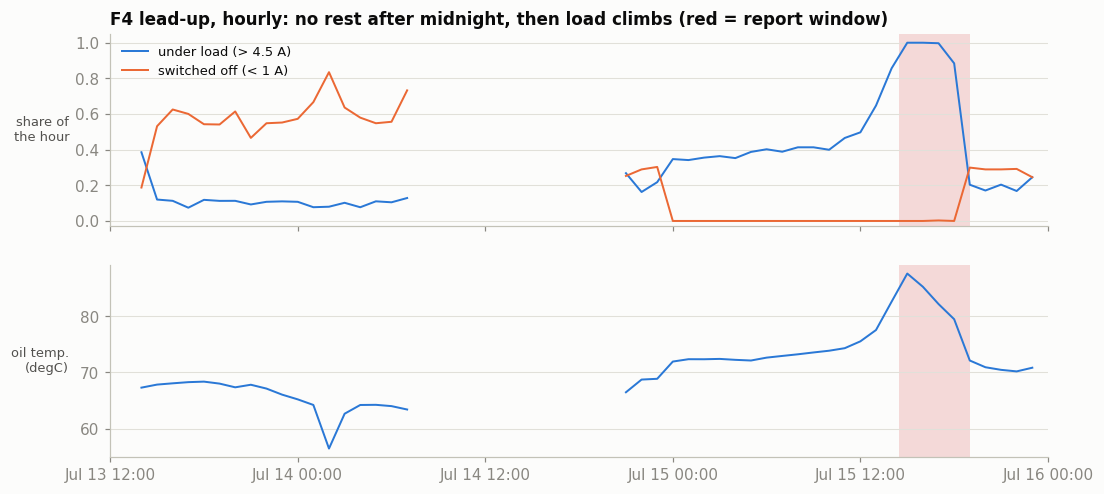

recording gap in the lead-up: Jul 14 07:16 to Jul 14 21:28 (14.2 h)
recording gap in the lead-up: Jul 13 12:59 to Jul 13 14:44 (1.8 h)
median hourly shares from Jul 13 12:00 to the long gap: under load 0.11, switched off 0.57
                     load share  rest share  oil (degC)
timestamp                                              
2020-07-14 21:00:00        0.27        0.25       66.48
2020-07-14 22:00:00        0.16        0.29       68.74
2020-07-14 23:00:00        0.22        0.30       68.88
2020-07-15 00:00:00        0.35        0.00       71.94
2020-07-15 01:00:00        0.34        0.00       72.36
2020-07-15 02:00:00        0.36        0.00       72.36
2020-07-15 03:00:00        0.36        0.00       72.42
2020-07-15 04:00:00        0.35        0.00       72.25
2020-07-15 05:00:00        0.39        0.00       72.13
2020-07-15 06:00:00        0.40        0.00       72.64
2020-07-15 07:00:00        0.39        0.00       72.94
2020-07-15 08:00:00        0.41        0.00   

In [29]:
motor_loaded = (tsu.Motor_current > 4.5).astype(float)
motor_off = (tsu.Motor_current < 1).astype(float)
z0, z1 = pd.Timestamp('2020-07-13 12:00'), pd.Timestamp('2020-07-16 00:00')
hourly = pd.DataFrame({'load share': motor_loaded.loc[z0:z1].resample('h').mean(),
                       'rest share': motor_off.loc[z0:z1].resample('h').mean(),
                       'oil (degC)': tsu.Oil_temperature.loc[z0:z1].resample('h').mean()})

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(hourly.index, hourly['load share'], color=BLUE, lw=1.3, label='under load (> 4.5 A)')
axes[0].plot(hourly.index, hourly['rest share'], color=ORANGE, lw=1.3, label='switched off (< 1 A)')
axes[0].set_ylim(-0.03, 1.05)
axes[0].set_ylabel('share of\nthe hour', rotation=0, ha='right', va='center', fontsize=8.5)
axes[0].legend(loc='upper left', frameon=False, fontsize=8.5)
axes[1].plot(hourly.index, hourly['oil (degC)'], color=BLUE, lw=1.3)
axes[1].set_ylabel('oil temp.\n(degC)', rotation=0, ha='right', va='center', fontsize=8.5)
for ax in axes:
    shade_failures(ax)
    ax.set_xlim(z0, z1)
    ax.grid(axis='x', visible=False)
axes[0].set_title('F4 lead-up, hourly: no rest after midnight, then load climbs '
                  '(red = report window)')
axes[1].xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
fig.align_ylabels(axes)
plt.show()

lead_gaps = big[(big.gap_end > z0) & (big.gap_start < FAILURE_WINDOWS[3][0]) & (big.delta_s >= 3600)]
for gs, ge, d in lead_gaps[['gap_start', 'gap_end', 'delta_s']].itertuples(index=False):
    print(f'recording gap in the lead-up: {gs:%b %d %H:%M} to {ge:%b %d %H:%M} ({d / 3600:.1f} h)')
before_gap = hourly.loc[:lead_gaps.gap_start.max()]
print(f"median hourly shares from Jul 13 12:00 to the long gap: under load {before_gap['load share'].median():.2f}, "
      f"switched off {before_gap['rest share'].median():.2f}")
print(hourly.loc['2020-07-14 21:00':'2020-07-15 18:00'].round(2).to_string())
peak = tsu.Oil_temperature.loc['2020-07-15'].idxmax()
print(f'oil maximum on Jul 15: {tsu.Oil_temperature.loc[peak]:.1f} degC at {peak:%H:%M} '
      f'(campaign maximum {tsu.Oil_temperature.max():.1f} degC)')

In [30]:
def share_alarms(signal, thr, window='6h', min_cover=0.5, hold_off=pd.Timedelta(hours=6)):
    # Onsets of `trailing share >= thr`, scored at every sample; a window holding less
    # than `min_cover` of its expected samples is not scored.
    share = signal.rolling(window).mean()
    cover = signal.rolling(window).count() / (pd.Timedelta(window).total_seconds() / step)
    on = (share >= thr) & (cover >= min_cover)
    onsets, last = [], None
    for t in on.index[on & ~on.shift(fill_value=False)]:
        if last is None or t - last >= hold_off:
            onsets.append(t)
            last = t
    return on, onsets

fail_zones = [(s - pd.Timedelta(hours=72), (r if r is not None else e) + BUFFER_AFTER)
              for (s, e, _), r in zip(FAILURE_WINDOWS, REPAIRS)]
unc_zones = [(s, e) for s, e, _ in UNCERTAIN]

def inside(t, zones):
    return any(a <= t <= b for a, b in zones)

# Negative time: recorded, unfrozen, outside the failure zones and the uncertain periods.
neg = np.ones(len(tsu), dtype=bool)
for a, b in fail_zones + unc_zones:
    neg &= ~((tsu.index >= a) & (tsu.index <= b))
neg_weeks = neg.sum() * step / (7 * 86400)

def evaluate(signal, thr):
    on, onsets = share_alarms(signal, thr)
    row = {}
    for i, (s, e, _) in enumerate(FAILURE_WINDOWS, start=1):
        before = on.loc[s - pd.Timedelta(hours=72): s]
        row[f'F{i} lead (h)'] = (round((s - before.index[before.to_numpy()][0]).total_seconds()
                                       / 3600, 1) if before.any() else '-')
    false_ = [t for t in onsets if not inside(t, fail_zones + unc_zones)]
    row['alarms, negative time'] = len(false_)
    row['per week'] = round(len(false_) / neg_weeks, 2)
    row['alarms, uncertain periods'] = sum(inside(t, unc_zones) and not inside(t, fail_zones)
                                           for t in onsets)
    return row

rule = {f'motor loaded, share >= {thr:.2f}': evaluate(motor_loaded, thr)
        for thr in (0.25, 0.30, 0.35)}
rule['DV_eletric = 1, share >= 0.25'] = evaluate(tsu.DV_eletric, 0.25)
print(f'6-hour trailing share, freezes masked; negative time = {neg_weeks:.1f} weeks of '
      'recorded data outside the failure zones (72 h before to 48 h after repair) '
      'and the uncertain periods')
pd.DataFrame(rule).T

6-hour trailing share, freezes masked; negative time = 19.5 weeks of recorded data outside the failure zones (72 h before to 48 h after repair) and the uncertain periods


,F1 lead (h),F2 lead (h),F3 lead (h),F4 lead (h),"alarms, negative time",per week,"alarms, uncertain periods"
"motor loaded, share >= 0.25",-,-,47.0,13.4,11,0.56,6
"motor loaded, share >= 0.30",-,-,-,10.6,5,0.26,6
"motor loaded, share >= 0.35",-,-,-,9.0,3,0.15,6
"DV_eletric = 1, share >= 0.25",-,-,59.3,35.6,13,0.67,6


In [31]:
# How much unfrozen data is there in the 72 h before each report?
avail = [((tsu.index >= s - pd.Timedelta(hours=72)) & (tsu.index < s)).sum() * step / 3600
         for s, e, _ in FAILURE_WINDOWS]
print('hours of unfrozen data in the 72 h before each report: '
      + ', '.join(f'F{i} {h:.1f}' for i, h in enumerate(avail, start=1)))

# F3: is off-load current (motor running, not loaded) elevated before the report?
offload = tsu.Motor_current[(tsu.Motor_current > 1) & (tsu.Motor_current <= 4.5)]
lo, hi = offload.quantile([0.05, 0.95])
before_f3 = offload.loc['2020-06-01':'2020-06-05 09:59:59'].resample('12h').median().dropna()
print(f'off-load current, campaign 5th-95th percentile: {lo:.2f}-{hi:.2f} A')
print('12-hour medians, Jun 1 to the F3 report: ' + ', '.join(f'{v:.2f}' for v in before_f3))
s3 = FAILURE_WINDOWS[2][0]
charges = [(a, b) for a, b in load_runs(0.5) if s3 - pd.Timedelta(hours=72) <= a and b < s3]
print('continuous load of 30 min or more in the 72 h before F3: '
      + ('; '.join(f'{a:%b %d %H:%M}-{b:%H:%M} ({(b - a).total_seconds() / 3600:.1f} h)'
                   for a, b in charges) or 'none'))

# Load commanded while the motor stays off.
cmd = ((tsu.DV_eletric == 1) & (tsu.Motor_current < 1)).astype(int)
per_hour = cmd.resample('h').sum()
hours = per_hour[per_hour >= 30]      # at least ~5 minutes in the hour
n_events = int((hours.index.to_series().diff() != pd.Timedelta(hours=1)).sum())
print(f'\nDV_eletric = 1 with Motor_current < 1 A: {cmd.mean():.2%} of samples '
      f'(COMP = 0 in {(tsu.COMP[cmd == 1] == 0).mean():.0%} of them); {len(hours)} clock hours '
      f'hold 5 minutes or more, in {n_events} separate events')
jul14 = cmd.loc['2020-07-14 00:00':'2020-07-14 06:00']
run_no = (jul14 != jul14.shift()).cumsum()[jul14 == 1]
ev = run_no.index[run_no == run_no.value_counts().idxmax()]      # longest run that night
restart = tsu.index[(tsu.index > ev[-1]) & (tsu.Motor_current > 4.5)][0]
print(f'Jul 14: load commanded with the motor off {ev[0]:%H:%M}-{ev[-1]:%H:%M}, motor loaded '
      f'again at {restart:%H:%M}; TP3 {tsu.TP3.loc[ev[0]]:.1f} bar at the start, '
      f'{tsu.TP3.loc[ev[0]:restart].min():.1f} bar at the lowest')
pd.DataFrame({'samples': hours,
              'TP3 min (bar)': tsu.TP3.resample('h').min()[hours.index].round(2)}) \
    .rename(index=lambda t: t.strftime('%b %d %H:00')).rename_axis(None)

hours of unfrozen data in the 72 h before each report: F1 51.1, F2 41.0, F3 60.7, F4 50.7
off-load current, campaign 5th-95th percentile: 3.65-3.93 A
12-hour medians, Jun 1 to the F3 report: 3.78, 3.73, 3.76, 3.79, 3.81, 3.75, 3.76, 3.75, 3.78
continuous load of 30 min or more in the 72 h before F3: Jun 03 10:06-11:10 (1.1 h)

DV_eletric = 1 with Motor_current < 1 A: 0.14% of samples (COMP = 0 in 100% of them); 15 clock hours hold 5 minutes or more, in 11 separate events
Jul 14: load commanded with the motor off 02:00-02:50, motor loaded again at 02:50; TP3 8.2 bar at the start, 4.9 bar at the lowest


,samples,TP3 min (bar)
Apr 06 11:00,148,7.71
Apr 25 00:00,156,6.91
Apr 25 01:00,66,6.49
May 19 01:00,60,6.98
May 19 02:00,246,4.69
Jun 02 19:00,301,5.57
Jul 14 02:00,303,4.94
Jul 17 01:00,30,1.45
Jul 18 01:00,35,7.52
Jul 28 03:00,35,7.61


## 6 · Healthy windows for detector training

The detector interface fits on healthy data only. The first run picked healthy *days* (at least
90 % coverage, two days clear of a failure) and found 80. That was too loose, because it let
logger freezes, unreported load episodes and pre-failure days through, and too strict, because a
day with one overnight stop is mostly usable.

Here healthy data is selected at window level, the way the pipeline will do it. A 10-minute window
on a fixed grid is *clean* when it holds at least 57 of its 60 samples and no step into or within
it exceeds 30 s. It is *healthy* when it is clean and touches none of the `events.yaml` v0.2
exclusions:

- from 7 days before each failure to 48 h after its repair (after the window end for F1, which has
  no repair time);
- the ten logger-freeze masks;
- the uncertain periods: the three heavy-LPS stretches and the six continuous-load episodes;
- the grey period, Jun 8 11:48–16:00.

That leaves **18,131 windows, about 126 days**: 3,518 in the February light-duty regime, 6,875 from
Mar 1 to the Jun 8 repair, and 7,738 after it. The freeze masks remove only two clean windows here,
because a frozen window holds 50 rows at 12 s and the 57-row rule already rejects it. They still
matter wherever data are resampled first, which is what the pipeline does.

The second table re-checks the day-level candidates in `events.yaml` against the same rule. H5 is
gone, H1 keeps only the days outside the Jun 30 – Jul 2 LPS stretch, H6 loses its last morning, H2
loses the Jul 21–22 freezes, and H3 is released now that its conflict turned out to be a freeze.

In [32]:
EPS = pd.Timedelta(seconds=1)       # event spans include their end instant
EXCLUSIONS = [(s - BUFFER_BEFORE, (r if r is not None else e) + BUFFER_AFTER, 'failure buffer')
              for (s, e, _), r in zip(FAILURE_WINDOWS, REPAIRS)]
EXCLUSIONS += [(s, e + EPS, 'logger freeze') for s, e in FREEZE_MASKS]
EXCLUSIONS += [(s, e if tag == 'lps_heavy' else e + EPS, tag) for s, e, tag in UNCERTAIN]
EXCLUSIONS += [(s, e + EPS, 'grey') for s, e in GREY]

win = df.timestamp.dt.floor('10min')
w = pd.DataFrame({'rows': win.groupby(win).size(),
                  'max_step_s': steps.groupby(win).max()})
w['clean'] = (w.rows >= 57) & (w.max_step_s <= 30)
starts = w.index
ends = starts + pd.Timedelta(minutes=10)
w['excluded by'] = ''
for s, e, why in EXCLUSIONS:
    hit = (starts < e) & (ends > s) & (w['excluded by'] == '').to_numpy()
    w.loc[hit, 'excluded by'] = why
w['healthy'] = w.clean & (w['excluded by'] == '')

edges = [pd.Timestamp('2020-02-01'), *REGIME_SPLITS, pd.Timestamp('2020-09-02')]
w['regime'] = pd.cut(starts, edges, right=False,
                     labels=['Feb (light duty)', 'Mar 1 to Jun 8 16:00', 'after Jun 8 16:00'])
by_regime = w.groupby('regime', observed=False).agg(clean=('clean', 'sum'),
                                                    healthy=('healthy', 'sum'))
by_regime.index = by_regime.index.astype(str)
by_regime.loc['total'] = by_regime.sum()
by_regime['healthy days'] = (by_regime.healthy * 10 / 1440).round(1)

lost = w.loc[w.clean & ~w.healthy, 'excluded by'].value_counts()
print(f'{int(w.clean.sum()):,} clean 10-minute windows; {int(w.healthy.sum()):,} healthy '
      f'after the v0.2 exclusions (~{w.healthy.sum() * 10 / 1440:.0f} days)')
print('clean windows lost, by first matching exclusion: '
      + ', '.join(f'{k} {v:,}' for k, v in lost.items()))

grid = w.healthy.reindex(pd.date_range(starts.min(), starts.max(), freq='10min'), fill_value=False)
run_no = (~grid).cumsum()[grid]
run_len = run_no.value_counts()
longest = run_no.index[run_no == run_len.idxmax()]
print(f'longest unbroken healthy stretch: {run_len.max() * 10 / 60:.1f} h, '
      f'{longest[0]:%b %d %H:%M} to {longest[-1] + pd.Timedelta(minutes=10):%b %d %H:%M}')
by_regime

23,943 clean 10-minute windows; 18,131 healthy after the v0.2 exclusions (~126 days)
clean windows lost, by first matching exclusion: failure buffer 3,932, lps_heavy 1,463, probable_leak 317, load_held 98, logger freeze 2
longest unbroken healthy stretch: 75.0 h, Mar 24 04:10 to Mar 27 07:10


,clean,healthy,healthy days
regime,,,
Feb (light duty),3518,3518,24.4
Mar 1 to Jun 8 16:00,10954,6875,47.7
after Jun 8 16:00,9471,7738,53.7
total,23943,18131,125.9


In [33]:
CANDIDATES = [('H1', '2020-06-29', '2020-07-05'), ('H2', '2020-07-18', '2020-07-22'),
              ('H3', '2020-06-13', '2020-06-16'), ('H4', '2020-03-21', '2020-03-23'),
              ('H5', '2020-05-06', '2020-05-08'), ('H6', '2020-03-25', '2020-03-27'),
              ('H7', '2020-08-06', '2020-08-08')]
cand = []
for cid, a, b in CANDIDATES:
    sub = w.loc[a: pd.Timestamp(b) + pd.Timedelta(hours=23, minutes=50)]
    lost_to = sorted(set(sub.loc[sub.clean & ~sub.healthy, 'excluded by']))
    cand.append({'candidate': cid,
                 'days': f'{pd.Timestamp(a):%b %d} to {pd.Timestamp(b):%b %d}',
                 'clean windows': int(sub.clean.sum()),
                 'healthy windows': int(sub.healthy.sum()),
                 'lost to': ', '.join(lost_to) or '-'})
print('Day-level healthy candidates from events.yaml, re-checked at window level:')
pd.DataFrame(cand).set_index('candidate')

Day-level healthy candidates from events.yaml, re-checked at window level:


,days,clean windows,healthy windows,lost to
candidate,,,,
H1,Jun 29 to Jul 05,990,559,lps_heavy
H2,Jul 18 to Jul 22,625,624,logger freeze
H3,Jun 13 to Jun 16,560,560,-
H4,Mar 21 to Mar 23,423,423,-
H5,May 06 to May 08,394,0,lps_heavy
H6,Mar 25 to Mar 27,432,405,load_held
H7,Aug 06 to Aug 08,415,415,-


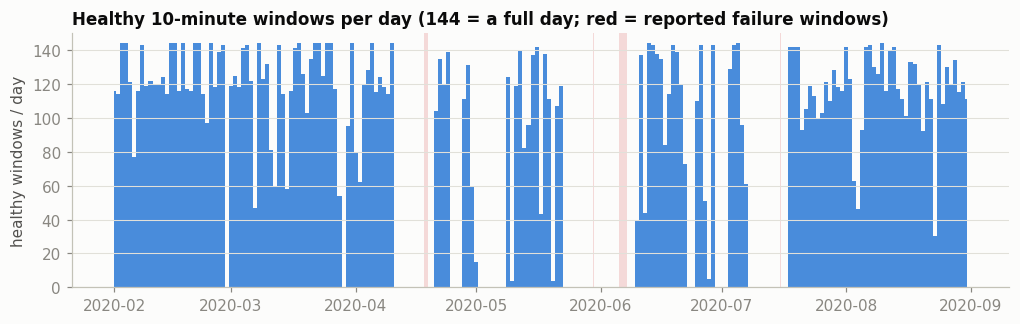

In [34]:
per_day = w.healthy.groupby(starts.floor('D')).sum()
per_day = per_day.reindex(pd.date_range('2020-02-01', '2020-08-31'), fill_value=0)
fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(per_day.index, per_day, step='mid', color=BLUE, alpha=0.85, lw=0)
shade_failures(ax)
ax.set_ylim(0, 150)
ax.set_ylabel('healthy windows / day')
ax.set_title('Healthy 10-minute windows per day (144 = a full day; red = reported failure windows)')
ax.grid(axis='x', visible=False)
plt.show()

## 7 · Data preprocessing

This section turns the raw file into the form every model will read: a regular 10 s grid, one zone
label per grid point, and 10-minute windows with a 1-minute stride. It follows the planned
`asset_profile.yaml` and `events.yaml` v0.2 and the gap policy. The functions involved
(`freeze_runs` from Section 2.2, then `to_grid`, `gap_edges`, `zone_codes`, `window_ends`,
`make_windows`, `add_folds` and `window_features`), fed by the raw gap table of Section 2.1, are
written to move into `pdm_common` (build guide R1a.4 and R1a.5); the move swaps the notebook
constants they read for the profile and events files. The outputs are saved at the end of Section 8.

### 7.1 · A regular 10 s grid

Frozen rows are dropped first, so a freeze becomes missing data instead of a flat line the resampler
could carry forward. The remaining rows go onto a fixed 10 s UTC grid. Analog channels take the mean
of the samples in each bin (12,840 bins hold two samples, because of the 9 s steps), and digital
channels take the last value. An interior run of one or two empty points is bridged (linear
interpolation for analog, forward fill for digital) and flagged. That covers every raw gap of 30 s or
less and, depending on where a gap falls against the bins, some shorter than 40 s. Anything longer
stays missing. The file has almost no short gaps: only 86 points are bridged, against about 1,078 h
missing to gaps and freezes.

In [35]:
STEP = '10s'           # asset_profile.yaml: sampling.resample_rule
MAX_BRIDGE_S = 30      # gap_policy.max_bridge_seconds

def to_grid(df, frozen, analog=ANALOG, digital=DIGITAL, step=STEP, max_bridge_s=MAX_BRIDGE_S):
    # Resample the raw rows onto a regular UTC grid with epoch-aligned bins. Frozen rows are
    # dropped first, so a freeze becomes missing data. Analog channels take the mean of each
    # bin, digital channels the last value. An interior run of empty bins is bridged when
    # (run + 1) x step <= max_bridge_s: analog interpolated in time, digital carried forward,
    # and flagged. Runs at either end of the data are never bridged.
    live = df.loc[~frozen, ['timestamp'] + analog + digital].set_index('timestamp')
    idx = pd.date_range(df.timestamp.min().floor(step), df.timestamp.max().floor(step),
                        freq=step, name='timestamp')
    a = live[analog].resample(step, origin='epoch').mean().reindex(idx)
    d = live[digital].resample(step, origin='epoch').last().reindex(idx)
    observed = a.notna().all(axis=1).to_numpy()
    missing = ~observed
    run_id = np.cumsum(np.r_[True, missing[1:] != missing[:-1]])
    run_len = np.bincount(run_id)[run_id]
    at_edge = (run_id == run_id[0]) | (run_id == run_id[-1])
    step_s = pd.Timedelta(step).total_seconds()
    bridged = missing & ~at_edge & ((run_len + 1) * step_s <= max_bridge_s)
    values_a = np.where(bridged[:, None], a.interpolate(method='time', limit_area='inside').to_numpy(),
                        a.to_numpy())
    values_d = np.where(bridged[:, None], d.ffill().to_numpy(), d.to_numpy())
    cols = {c: values_a[:, j] for j, c in enumerate(analog)}
    cols.update({c: values_d[:, j] for j, c in enumerate(digital)})
    grid = pd.DataFrame(cols, index=idx)
    grid['observed'] = observed
    grid['bridged'] = bridged
    return grid

grid = to_grid(df, frozen)
grid_valid = (grid.observed | grid.bridged).to_numpy()
two_samples = int((df.timestamp[~frozen].dt.floor(STEP).value_counts() > 1).sum())
counts = pd.Series({'observed': int(grid.observed.sum()),
                    'bridged (a run of one or two empty points)': int(grid.bridged.sum()),
                    'missing (gaps and freezes)': int((~grid_valid).sum())})
print(f'{len(grid):,} grid points of 10 s, {grid.index[0]} to {grid.index[-1]}')
print(f'bins holding two samples (from 9 s steps), averaged: {two_samples:,}')
pd.DataFrame({'grid points': counts, 'hours': (counts / 360).round(2)})

1,841,760 grid points of 10 s, 2020-02-01 00:00:00 to 2020-09-01 03:59:50
bins holding two samples (from 9 s steps), averaged: 12,840


,grid points,hours
observed,1453431,4037.31
bridged (a run of one or two empty points),86,0.24
missing (gaps and freezes),388243,1078.45


### 7.2 · Zones

Every grid point gets exactly one zone, in order of precedence:

1. **masked** — a logger freeze;
2. **positive** — a report window with its guard band, 24 h before and 12 h after;
3. **grey** — the uncertain periods, the Jun 8 grey period, the first 15 minutes after each recording
   gap of 30 minutes or more (the gap edges of `events.yaml`), and the rest of each healthy buffer;
4. **negative** — everything else.

The data set the gap edge. When recording resumes after a stop, TP3 is below its healthy 1st
percentile in 58 % of the 190 cases, against 4 % fifteen minutes later. Before a stop the share
stays flat at 6–10 %, with no transient, so the shutdown side needs no edge. Gaps are raw timestamp
gaps; a freeze keeps its timestamps and gets no edge.

Negative time is the only detector training data. Grey time is scored, and alarms there are audited
rather than counted as false. An alarm in positive time counts as a detection. Lead time is measured
back from the report start at the 2, 24 and 72 h horizons of `events.yaml`, so at 72 h the harness
also reads alarms in the buffer before the guard band; how it scores those is its call (R1b.3). The
`zone_detail` column keeps the finer label, so the false-alarm rate can be reported with and without
the uncertain periods. With data, that is about 3,025 h of negative time, 828 h grey and 184 h
positive.

In [36]:
GUARD_BEFORE = pd.Timedelta(hours=24)   # events.yaml guard_band.before
GUARD_AFTER = pd.Timedelta(hours=12)    # events.yaml guard_band.after
STOP_MIN = pd.Timedelta(minutes=30)     # a recording gap this long counts as a stop
GAP_EDGE = pd.Timedelta(minutes=15)     # events.yaml "gap edges": grey after a stop (see below)
ZONE_DETAIL = ['negative', 'buffer', 'gap_edge', 'grey_period', 'uncertain:lps_heavy',
               'uncertain:load_held', 'uncertain:probable_leak', 'failure', 'masked']
ZONE_OF = np.array(['negative', 'grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'positive', 'masked'])
CODE = {name: i for i, name in enumerate(ZONE_DETAIL)}

def gap_edges(gaps, min_gap=STOP_MIN, length=GAP_EDGE, step=STEP):
    # Grey spans after each recording gap of min_gap or more. `gaps` holds raw-timestamp gaps
    # (gap_start, gap_end, delta_s), so a freeze, which keeps its timestamps, is not a gap.
    stops = gaps[gaps.delta_s >= pd.Timedelta(min_gap).total_seconds()]
    return [(t.floor(step), t + length) for t in stops.gap_end.sort_values()]

stops = big[big.delta_s >= STOP_MIN.total_seconds()].sort_values('gap_end')
GAP_EDGES = gap_edges(big)

def zone_codes(times, gap_edges=GAP_EDGES):
    # One code per timestamp (index into ZONE_DETAIL); the higher code wins where spans
    # overlap. `times` must be sorted.
    code = np.zeros(len(times), dtype=np.int8)
    def paint(start, end, c, closed=True):
        i0, i1 = times.searchsorted(start), times.searchsorted(end, side='right' if closed else 'left')
        code[i0:i1] = np.maximum(code[i0:i1], c)
    for (s, e, _), r in zip(FAILURE_WINDOWS, REPAIRS):
        paint(s - BUFFER_BEFORE, (r if r is not None else e) + BUFFER_AFTER, CODE['buffer'], closed=False)
        paint(s - GUARD_BEFORE, e + GUARD_AFTER, CODE['failure'])
    for s, e in gap_edges:
        paint(s, e, CODE['gap_edge'], closed=False)
    for s, e in GREY:
        paint(s, e, CODE['grey_period'])
    for s, e, tag in UNCERTAIN:
        paint(s, e, CODE['uncertain:' + tag], closed=(tag != 'lps_heavy'))
    for s, e in FREEZE_MASKS:
        paint(s, e, CODE['masked'])
    return code

grid['zone_code'] = zone_codes(grid.index)
grid['zone'] = pd.Categorical(ZONE_OF[grid.zone_code], categories=['negative', 'grey', 'positive', 'masked'])
grid['zone_detail'] = pd.Categorical(np.array(ZONE_DETAIL)[grid.zone_code], categories=ZONE_DETAIL)

# Why 15 minutes: TP3 right after each stop, against the healthy 1st percentile.
tp3 = grid.TP3.to_numpy()
p1 = np.nanpercentile(tp3[(grid.zone_code.to_numpy() == 0) & grid_valid], 1)
first = grid.index.searchsorted(stops.gap_end, side='right') - 1  # first point after the gap
last = grid.index.searchsorted(stops.gap_start, side='right') - 1  # last point before it
low = {}
for m in [0, 5, 10, 15, 30]:
    after, before = tp3[np.minimum(first + 6 * m, len(tp3) - 1)], tp3[np.maximum(last - 6 * m, 0)]
    low[f'{m} min'] = {'after the stop': (after[~np.isnan(after)] < p1).mean(),
                       'before the stop': (before[~np.isnan(before)] < p1).mean()}
print(f'{len(stops)} recording gaps of 30 min or more. Share with TP3 below the healthy 1st '
      f'percentile ({p1:.2f} bar), by minutes from the gap:')
print(pd.DataFrame(low).round(2).to_string())

zone_hours = pd.DataFrame({
    'zone': pd.Series(ZONE_OF, index=ZONE_DETAIL),
    'hours': grid.groupby('zone_detail', observed=False).size() / 360,
    'hours with data': grid[grid_valid].groupby('zone_detail', observed=False).size() / 360,
}).round(1)
zone_hours

190 recording gaps of 30 min or more. Share with TP3 below the healthy 1st percentile (8.08 bar), by minutes from the gap:
                 0 min  5 min  10 min  15 min  30 min
after the stop    0.58   0.21    0.07    0.04    0.04
before the stop   0.09   0.06    0.09    0.09    0.10


,zone,hours,hours with data
negative,negative,3691.8,3024.9
buffer,grey,597.0,457.8
gap_edge,grey,43.7,39.8
grey_period,grey,4.2,3.7
uncertain:lps_heavy,grey,312.0,246.1
uncertain:load_held,grey,27.8,27.8
uncertain:probable_leak,grey,53.1,53.1
failure,positive,216.5,184.3
masked,masked,169.8,0.0


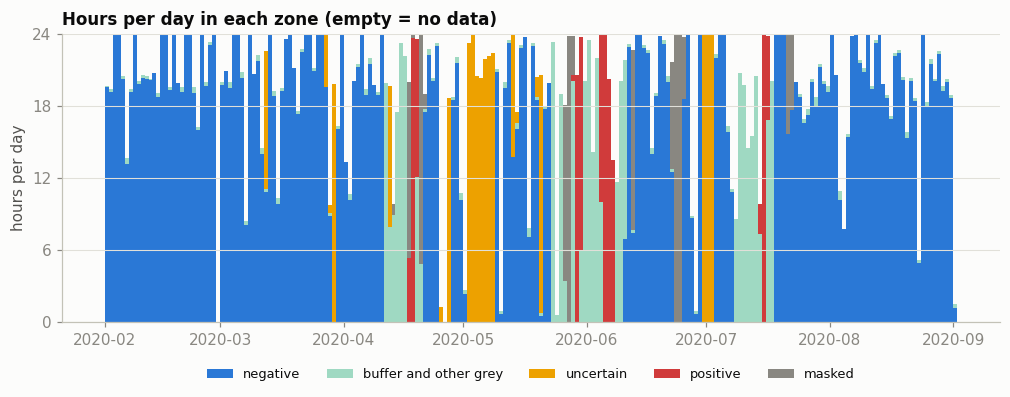

In [37]:
# Hours per day in each zone; freezes get their own colour and missing data is left empty.
kind = np.select([grid.zone_code == CODE['masked'], ~grid_valid, grid.zone_code == CODE['failure'],
                  grid.zone_code >= CODE['uncertain:lps_heavy'], grid.zone_code >= CODE['buffer']],
                 ['masked', 'no data', 'positive', 'uncertain', 'buffer and other grey'], default='negative')
per_day = pd.crosstab(grid.index.floor('D'), kind) / 360
ZONE_STYLE = [('negative', BLUE), ('buffer and other grey', '#9fd9c2'), ('uncertain', YELLOW),
              ('positive', CRITICAL), ('masked', MUTED)]
fig, ax = plt.subplots(figsize=(11, 3.4))
bottom = np.zeros(len(per_day))
for name, colour in ZONE_STYLE:
    hours = per_day[name].to_numpy() if name in per_day else np.zeros(len(per_day))
    ax.bar(per_day.index, hours, bottom=bottom, width=1.0, align='edge', color=colour, lw=0, label=name)
    bottom += hours
ax.set_ylim(0, 24)
ax.set_yticks([0, 6, 12, 18, 24])
ax.set_ylabel('hours per day')
ax.set_title('Hours per day in each zone (empty = no data)')
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=8.5)
ax.grid(axis='x', visible=False)
plt.show()

### 7.3 · Windows

Windows are 10 minutes (60 grid points) with a 1-minute stride, each starting on the full minute, and
a window takes the highest-precedence zone any of its points has. A window is complete when all 60
points are observed or bridged. Incomplete windows are dropped, never repaired. One more rule applies
at window level: a negative window whose 6 h look-back reaches an uncertain period becomes grey
(`after_uncertain`, 1,373 windows). After a load episode its 6 h shares still carry the episode, and
the rule treats every uncertain period the same way. Of 306,951 candidate windows, 239,172 are
complete, and 177,973 of those are negative.

Under Section 6's exclusions (no gap edges, no look-back rule), 18,130 non-overlapping negative
windows are complete on the grid, one fewer than Section 6's 18,131. The 17 that differ come from how
each side reads missing data, printed below. Nine have a gap starting before they end, which Section
6 does not look past. Six start as data resume, where Section 6 counts the long step into the window.
The last two fall on Mar 11, 18:30 to 18:50, where rows arrive every 12 s and the grid bridges the
empty points. With the gap edges and the look-back rule the count is 17,810, and that is what the
pipeline test should expect.

In [38]:
WIN_BINS = 60                      # windowing.length: 10 min of 10 s points
WIN_LEN = pd.Timedelta(minutes=10)
LOOKBACK = pd.Timedelta(hours=6)   # longest short look-back among the features (load and rest share)

def window_ends(grid, win_bins=WIN_BINS):
    # Grid positions of the last point of every window that starts on a full minute
    # (windowing.stride: 1 min).
    last = np.arange(win_bins - 1, len(grid))
    return last[grid.index[last - (win_bins - 1)].second == 0]

def make_windows(grid, ends, win_bins=WIN_BINS, lookback=LOOKBACK, step=STEP):
    # One row per window: complete when all points are observed or bridged; the zone is the
    # highest-precedence zone of its own points. A negative window whose look-back (`lookback`
    # before its start) reaches an uncertain period or a report becomes grey, 'after_uncertain':
    # after a load episode its 6 h shares still carry it. (In 2020 a report never reaches a
    # negative window this way; the buffers keep them at least 36 h apart.)
    valid = (grid.observed | grid.bridged).astype('int16')
    n_valid = valid.rolling(win_bins).sum().to_numpy()[ends]
    top = grid.zone_code.rolling(win_bins).max().to_numpy()[ends].astype(int)
    episode = grid.zone_code.between(CODE['uncertain:lps_heavy'], CODE['failure']).astype('int8')
    reach = win_bins + int(lookback / pd.Timedelta(step))
    touched = episode.rolling(reach, min_periods=1).max().to_numpy()[ends] > 0
    zone = ZONE_OF[top].astype(object)
    detail = np.array(ZONE_DETAIL, dtype=object)[top]
    after = (zone == 'negative') & touched
    zone[after], detail[after] = 'grey', 'after_uncertain'
    start = grid.index[ends - (win_bins - 1)]
    out = pd.DataFrame({'window_start': start, 'window_end': start + WIN_LEN,
                        'complete': n_valid == win_bins, 'zone': zone, 'zone_detail': detail})
    out['regime'] = pd.cut(out.window_start, [pd.Timestamp('2020-02-01'), *REGIME_SPLITS,
                                              pd.Timestamp('2020-09-02')],
                           right=False, labels=['light_duty', 'normal', 'dv_pressure_flat'])
    return out

win_end_pos = window_ends(grid)
windows_all = make_windows(grid, win_end_pos)
done = windows_all[windows_all.complete]
print(f'{len(windows_all):,} candidate windows; {len(done):,} complete '
      f'({len(windows_all) - len(done):,} dropped for missing data or freezes)')

# Cross-check with Section 6, which applies the same exclusions without the gap edges and the
# look-back rule: count non-overlapping negative windows both ways.
on_ten = (windows_all.window_start.dt.minute % 10 == 0).to_numpy()
base_top = pd.Series(zone_codes(grid.index, gap_edges=[])).rolling(WIN_BINS).max().to_numpy()[win_end_pos]
base = windows_all[windows_all.complete.to_numpy() & on_ten & (base_top == 0)]
swap = sorted(set(base.window_start) ^ set(w.index[w.healthy]))
gap_t = grid.index[~grid_valid]
def seconds_to_missing(ws):
    # Distance from the window [ws, ws + 10 min) to the nearest missing grid point.
    i, j = gap_t.searchsorted(ws), gap_t.searchsorted(ws + WIN_LEN)
    if j > i:
        return 0.0
    near = [ws - gap_t[i - 1] if i > 0 else pd.Timedelta.max, gap_t[j] - (ws + WIN_LEN) if j < len(gap_t) else pd.Timedelta.max]
    return min(near).total_seconds()
sw = pd.DataFrame({'start': swap})
sw['grid_only'] = sw.start.isin(set(base.window_start))
sw['to_missing_s'] = [seconds_to_missing(t) for t in sw.start]
sw['s6_max_step_s'] = w.max_step_s.reindex(sw.start).to_numpy()
only6, only_grid = sw[~sw.grid_only], sw[sw.grid_only]
resume, slow = only_grid[only_grid.to_missing_s <= 10], only_grid[only_grid.to_missing_s > 10]
print(f'Section 6 check: {len(base):,} non-overlapping negative windows on the grid against '
      f'{int(w.healthy.sum()):,} there. Of the {len(swap)} that differ:')
print(f'  {len(only6)} pass only in Section 6; {int((only6.to_missing_s == 0).sum())} of them have a missing '
      'grid point inside (a gap starts before the window ends)')
print(f'  {len(resume)} pass only on the grid and start as data resume; Section 6 counts the step into '
      f'the window ({resume.s6_max_step_s.min():.0f} s to {resume.s6_max_step_s.max() / 3600:.0f} h)')
if len(slow):
    print(f'  {len(slow)} pass only on the grid, on {slow.start.min():%b %d %H:%M}-{slow.start.max() + WIN_LEN:%H:%M}, '
          f'where rows arrive every {WIN_LEN.total_seconds() / w.rows.reindex(slow.start).mean():.0f} s '
          f'(steps up to {slow.s6_max_step_s.max():.0f} s) and the grid bridges the empty points')
aligned_neg = done[on_ten[windows_all.complete.to_numpy()] & (done.zone == 'negative').to_numpy()]
print(f'with the gap edges and the look-back rule: {len(aligned_neg):,} non-overlapping negative '
      'windows; by regime: ' + ', '.join(f'{k} {v:,}' for k, v in aligned_neg.regime.value_counts(sort=False).items()))
done.zone_detail.value_counts().rename('complete windows').to_frame()

306,951 candidate windows; 239,172 complete (67,779 dropped for missing data or freezes)
Section 6 check: 18,130 non-overlapping negative windows on the grid against 18,131 there. Of the 17 that differ:
  9 pass only in Section 6; 9 of them have a missing grid point inside (a gap starts before the window ends)
  6 pass only on the grid and start as data resume; Section 6 counts the step into the window (129 s to 28 h)
  2 pass only on the grid, on Mar 11 18:30-18:50, where rows arrive every 12 s (steps up to 13 s) and the grid bridges the empty points
with the gap edges and the look-back rule: 17,810 non-overlapping negative windows; by regime: light_duty 3,496, normal 6,676, dv_pressure_flat 7,638


,complete windows
zone_detail,
negative,177973
buffer,27018
uncertain:lps_heavy,14663
failure,10958
uncertain:probable_leak,3187
gap_edge,2094
uncertain:load_held,1696
after_uncertain,1373
grey_period,210


### 7.4 · Evaluation blocks and the calibration split

Leave-one-event-out needs a test block per event: its healthy buffer, from 7 days before the report
to 48 h after the repair (after the report's end for F1). F2 and F3 are six days apart, so their
buffers overlap. Following `events.yaml`, the blocks are asymmetric: a block stops short of another
event's positive zone and never holds another event's positive windows. F3's block therefore starts
at May 30 18:00, where F2's guard band ends, and the two blocks share only 2,223 grey windows. The
`event` column tags each positive window with its event, so lead time is scored per event and F2 and
F3 are reported as a pair.

Negative windows lie outside every block, so a detector that reads the raw sequences sees the same
training data in every fold. The engineered channels look back further: a negative window up to
7 days after a block still reads it through `tp3_deficit_7d`. The `lookback_F1` to `lookback_F4`
columns flag those windows (4,900, 0, 8,541 and 8,537), and fold *i* leaves them out of fitting and
calibration. Beyond that, the folds matter for anything tuned on the events themselves, such as the
load-share threshold or the persistence gate.

Calibration also must not reuse the windows a detector was fitted on. Negative windows therefore
alternate between a `fit` half (86,430) and a `calibrate` half (91,543) by ISO calendar week, which
keeps neighbouring windows together apart from the few that straddle a Monday midnight. Both halves
cover all three regimes. Non-negative windows carry `none` in `neg_split`, and every window that is
not positive carries `none` in `event`.

In [39]:
def add_folds(win):
    # Leave-one-event-out columns. Test block: the event's healthy buffer, 7 days before the
    # report to 48 h after the repair (after the report's end without a repair). A block stops
    # short of another event's positive zone and never holds another event's positive windows,
    # so F3's block starts where F2's guard band ends (the asymmetric blocks of events.yaml).
    # Adds event, block_F*, lookback_F* and neg_split; returns the block spans.
    event = np.full(len(win), 'none', dtype=object)
    for i, (s, e, _) in enumerate(FAILURE_WINDOWS, start=1):
        touches = (win.window_start <= e + GUARD_AFTER) & (win.window_end > s - GUARD_BEFORE)
        event[(win.zone == 'positive').to_numpy() & touches.to_numpy()] = f'F{i}'
    win['event'] = event
    positive_zone = [(s - GUARD_BEFORE, e + GUARD_AFTER) for s, e, _ in FAILURE_WINDOWS]
    spans = {}
    for i, ((s, e, _), r) in enumerate(zip(FAILURE_WINDOWS, REPAIRS)):
        a, b = s - BUFFER_BEFORE, (r if r is not None else e) + BUFFER_AFTER
        for j, (ps, pe) in enumerate(positive_zone):
            if j < i and pe > a:
                a = pe
            if j > i and ps < b:
                b = ps
        fold = f'F{i + 1}'
        spans[fold] = (a, b)
        other = (win.event != 'none') & (win.event != fold)
        win[f'block_{fold}'] = (win.window_start < b) & (win.window_end > a) & ~other
        # Negative windows outside the block whose 7-day look-back reaches into it.
        reach = (win.window_start - pd.Timedelta(days=7) < b) & (win.window_end > a)
        win[f'lookback_{fold}'] = reach & ~win[f'block_{fold}'] & (win.zone == 'negative')
    # Threshold calibration must never see training scores: negative windows alternate between
    # 'fit' and 'calibrate' by ISO calendar week, so neighbouring windows mostly share a side.
    week = win.window_start.dt.isocalendar().week.astype(int).to_numpy()
    win['neg_split'] = np.where(win.zone != 'negative', 'none', np.where(week % 2 == 0, 'fit', 'calibrate'))
    return spans

BLOCKS = add_folds(windows_all)
blocks = []
for fold, (a, b) in BLOCKS.items():
    in_block = windows_all.complete & windows_all[f'block_{fold}']
    other = (windows_all.event != 'none') & (windows_all.event != fold)
    blocks.append({'fold': fold, 'test block': f'{a:%b %d %H:%M} to {b:%b %d %H:%M}',
                   'complete windows': int(in_block.sum()),
                   'positive, own event': int((in_block & (windows_all.event == fold)).sum()),
                   'positive, other events': int((in_block & other).sum()),
                   'negative with look-back into it': int((windows_all.complete & windows_all[f'lookback_{fold}']).sum())})
overlap = windows_all.complete & windows_all.block_F2 & windows_all.block_F3
print(f'F2 and F3 test blocks share {int(overlap.sum()):,} windows, all of them '
      f'{"/".join(sorted(windows_all.zone_detail[overlap].unique()))} '
      f'({windows_all.window_start[overlap].min():%b %d %H:%M} to {windows_all.window_end[overlap].max():%b %d %H:%M})')
neg_done = windows_all[windows_all.complete & (windows_all.zone == 'negative')]
print('negative windows by regime and split:')
print(pd.crosstab(neg_done.regime, neg_done.neg_split, margins=True).to_string())
pd.DataFrame(blocks).set_index('fold')

F2 and F3 test blocks share 2,223 windows, all of them buffer/gap_edge (May 30 18:01 to Jun 01 12:09)
negative windows by regime and split:
neg_split         calibrate    fit     All
regime                                    
light_duty            17475  17470   34945
normal                31530  35163   66693
dv_pressure_flat      42538  33797   76335
All                   91543  86430  177973


,test block,complete windows,"positive, own event","positive, other events",negative with look-back into it
fold,,,,,
F1,Apr 11 00:00 to Apr 20 23:59,9961,2397,0,4900
F2,May 22 23:30 to Jun 01 12:00,8424,2297,0,0
F3,May 30 18:00 to Jun 10 16:00,12701,4280,0,8541
F4,Jul 08 14:30 to Jul 18 00:00,10397,1984,0,8537


## 8 · Feature engineering

Features are computed per window from the grid, using only grid points up to the window's last point.
The two exceptions sit upstream, in bridging and the freeze masks (Section 8.5). There are three
groups:

- **summary statistics** of the five detector inputs: mean, standard deviation, minimum, maximum and
  the change across the window;
- **five engineered channels** that the EDA points to;
- **two data-quality flags** that feed the diagnostic checks rather than the detector.

Deep detectors read the raw 60-point sequences from the saved grid instead of the summaries.

### 8.1 · The engineered channels

- **`load_share_6h`, `rest_share_6h`**: the share of the trailing 6 h with the motor loaded (above
  4.5 A) or stopped (below 1 A), scored only when at least half of the 6 h has data. They carry the
  F4 lead-up (Section 5.2). They use motor current because DV_eletric reads 1 with the motor off in
  parts of 15 clock hours (Section 5.2).
- **`hours_since_rest`**: hours since the motor last stopped. In normal operation the motor stops
  every few minutes, so the value sits near zero, and F4's morning and every continuous-load episode
  show up as a steady climb. A data gap or masked freeze of 30 minutes or more counts as a stop,
  because the motor's state there is unknown; a rest inside a shorter gap is missed.
- **`tp3_deficit_7d`**: the window's mean TP3 minus its mean over the 7 days before the window,
  scored when at least a quarter of those 7 days has data. This is the pressure drop that separates
  the leaks from heavy demand (Section 5.1).
- **`oil_rise_1h`**: the window's mean oil temperature minus the same an hour earlier.

The table lists these and the two flags; `feature_dictionary.csv` holds all 32 features.

In [40]:
INPUTS = ['TP2', 'TP3', 'H1', 'Oil_temperature', 'Motor_current']   # detector inputs, profile v0.2
LOADED_A, REST_A = 4.5, 1.0     # motor loaded above, stopped below (Section 4.1)

def bins(duration, step=STEP):
    # Number of grid points in a duration.
    return int(pd.Timedelta(duration) / pd.Timedelta(step))

SIX_H, WEEK, HOUR, STOP_BINS = bins('6h'), bins('7D'), bins('1h'), bins(STOP_MIN)

def window_features(grid, ends, win_bins=WIN_BINS):
    # Features per window, using only grid points up to the window's last point. The two
    # exceptions sit upstream: bridging in to_grid and the freeze masks (Section 8.5).
    t = grid.index
    valid = grid.observed | grid.bridged
    x = grid[INPUTS].copy()
    x[~valid.to_numpy()] = np.nan
    out = {}
    for c in INPUTS:                                   # summary statistics per input
        roll = x[c].rolling(win_bins, min_periods=win_bins)
        out[f'{c}_mean'] = roll.mean().to_numpy()[ends]
        out[f'{c}_std'] = roll.std().to_numpy()[ends]
        out[f'{c}_min'] = roll.min().to_numpy()[ends]
        out[f'{c}_max'] = roll.max().to_numpy()[ends]
        out[f'{c}_slope'] = (x[c] - x[c].shift(win_bins - 1)).to_numpy()[ends]
    current = x.Motor_current
    have = valid.astype(float).rolling(SIX_H, min_periods=1).sum()
    enough = (have >= SIX_H / 2).to_numpy()            # score only with half the 6 h present
    for name, state in [('load_share_6h', current > LOADED_A), ('rest_share_6h', current < REST_A)]:
        share = state.astype(float).where(valid).rolling(SIX_H, min_periods=1).sum() / have
        out[name] = np.where(enough, share.to_numpy(), np.nan)[ends]
    missing = ~valid.to_numpy()                        # hours since the motor last stopped; a
    run_id = np.cumsum(np.r_[True, missing[1:] != missing[:-1]])   # gap or freeze of 30 min
    long_gap = missing & (np.bincount(run_id)[run_id] >= STOP_BINS)   # counts as a stop
    stopped = (current < REST_A).to_numpy() | long_gap
    last_stop = pd.Series(t.where(stopped), index=t).ffill()
    since = (pd.Series(t, index=t) - last_stop).dt.total_seconds() / 3600
    out['hours_since_rest'] = since.where(valid).to_numpy()[ends]
    before = x.TP3.rolling(WEEK, min_periods=WEEK // 4).mean().shift(win_bins)
    out['tp3_deficit_7d'] = out['TP3_mean'] - before.to_numpy()[ends]   # vs the 7 days before
    oil = x.Oil_temperature.rolling(win_bins, min_periods=win_bins).mean()
    out['oil_rise_1h'] = (oil - oil.shift(HOUR)).to_numpy()[ends]
    cmd = ((grid.DV_eletric == 1) & (grid.Motor_current < REST_A) & valid).astype(float)
    out['cmd_motor_off'] = cmd.rolling(win_bins, min_periods=1).sum().to_numpy()[ends]
    out['n_bridged'] = grid.bridged.astype(float).rolling(win_bins, min_periods=1).sum().to_numpy()[ends]
    return pd.DataFrame(out)

feats = window_features(grid, win_end_pos)
FEATURES = list(feats.columns)
windows = pd.concat([windows_all, feats], axis=1)
windows = windows[windows.complete].drop(columns='complete').reset_index(drop=True)
print(f'{len(FEATURES)} features on {len(windows):,} complete windows')

STAT = {'mean': 'mean over the window', 'std': 'standard deviation over the window',
        'min': 'minimum over the window', 'max': 'maximum over the window',
        'slope': 'last point minus first point of the window'}
rows = [(f'{c}_{k}', f'{c}: {v}', UNITS[c], '10 min', 'summary statistic')
        for c in INPUTS for k, v in STAT.items()]
rows += [
    ('load_share_6h', 'share of the trailing 6 h with Motor_current > 4.5 A (half the 6 h must have data)', 'share', '6 h', 'engineered'),
    ('rest_share_6h', 'share of the trailing 6 h with Motor_current < 1 A (same coverage rule)', 'share', '6 h', 'engineered'),
    ('hours_since_rest', 'hours since Motor_current was last below 1 A; a data gap or freeze of 30 min or more counts as a stop, a rest inside a shorter gap is missed', 'h', 'unbounded', 'engineered'),
    ('tp3_deficit_7d', 'window mean of TP3 minus its mean over the 7 days before the window (scored with at least a quarter of those days present)', 'bar', '7 days', 'engineered'),
    ('oil_rise_1h', 'window mean of Oil_temperature minus the same an hour earlier', 'degC', '1 h 10 min', 'engineered'),
    ('cmd_motor_off', 'points with DV_eletric = 1 while Motor_current < 1 A (load commanded, motor off)', 'count', '10 min', 'data-quality flag'),
    ('n_bridged', 'bridged points in the window', 'count', '10 min', 'data-quality flag'),
]
FEATURE_DICT = pd.DataFrame(rows, columns=['feature', 'definition', 'unit', 'look-back', 'role'])
assert list(FEATURE_DICT.feature) == FEATURES
FEATURE_DICT[FEATURE_DICT.role != 'summary statistic'].set_index('feature')

32 features on 239,172 complete windows


,definition,unit,look-back,role
feature,,,,
load_share_6h,share of the trailing 6 h with Motor_current >...,share,6 h,engineered
rest_share_6h,share of the trailing 6 h with Motor_current <...,share,6 h,engineered
hours_since_rest,hours since Motor_current was last below 1 A; ...,h,unbounded,engineered
tp3_deficit_7d,window mean of TP3 minus its mean over the 7 d...,bar,7 days,engineered
oil_rise_1h,window mean of Oil_temperature minus the same ...,degC,1 h 10 min,engineered
cmd_motor_off,points with DV_eletric = 1 while Motor_current...,count,10 min,data-quality flag
n_bridged,bridged points in the window,count,10 min,data-quality flag


### 8.2 · Where the features move

Each cell compares the windows in one phase of one event with healthy windows of the same regime, as
an AUROC: 0.5 means no separation, and values near 1 or 0 mean the feature sits almost entirely above
or below healthy data. The last two columns compare the unreported episodes the same way.

- **During the reports, the load features separate almost completely.** `TP2_mean`,
  `Motor_current_mean`, `Oil_temperature_mean`, load share and hours since rest sit at 0.99–1.00, and
  rest share at 0.00–0.07: the continuous-load signature again. The pressure deficit separates F2 and
  F3 strongly (0.04 and 0.00) and F1 and F4 less (0.30).
- **Before the reports, only F4 shows that signature, and only in its last 24 h**: load share 1.00,
  rest share 0.00, hours since rest 0.94, oil 0.97. F2 and F3 lean the same way more weakly (load
  share 0.62–0.77, oil 0.70–0.90). Part of that may not be the leaks: healthy windows were already
  warmer and busier in the regime's last healthy week, May 17–22 (oil 66 °C against 57–65 °C before,
  load share 0.20 against 0.07–0.16; table below the chart). That could be the season, or an early
  stage of F2, which Section 5.1 raises for the May episodes. F1's lead-up runs the other way, cooler
  and quieter than normal (oil 0.13–0.29), and its last 24 h are mostly frozen.
- **Only the TP3 features tell the unreported probable leaks from the pressure-held episodes**
  (`tp3_deficit_7d` 0.07 against 0.76, `TP3_mean` 0.06 against 0.80). Every load feature separates
  both almost completely (0.98–1.00, rest share 0.02–0.05). `oil_rise_1h` stays near 0.5 almost
  everywhere, so it adds little.

This is descriptive. With four events, every event column that separates is still a single event.

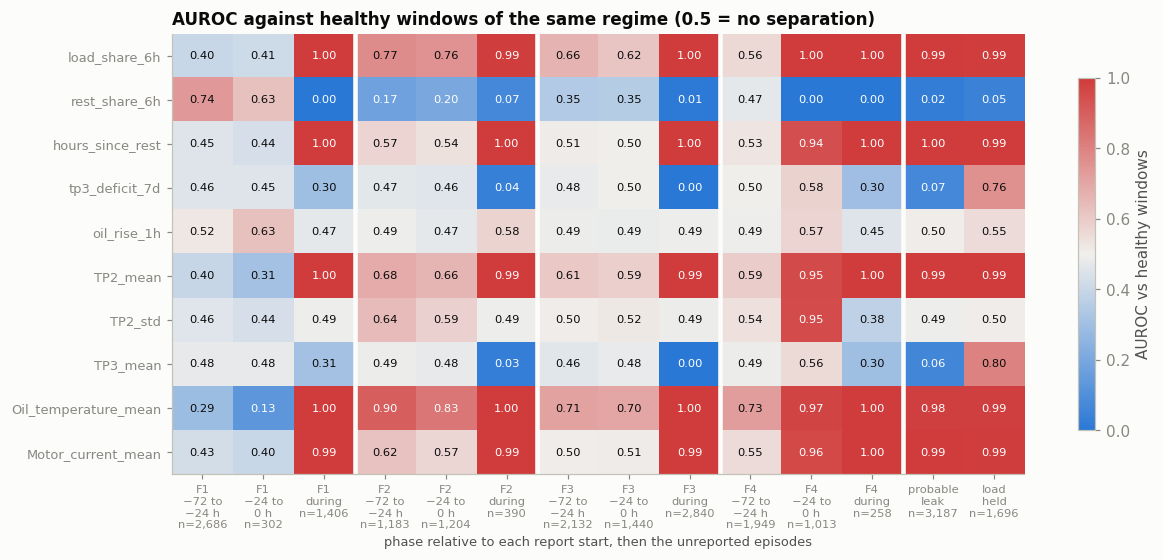

week from,Mar 01,Mar 08,Mar 15,Mar 22,Mar 29,Apr 05,Apr 19,Apr 26,May 03,May 10,May 17
oil temperature (deg C),65.3,62.2,57.3,60.5,61.3,59.8,56.8,57.7,58.2,56.6,66.2
load share (6 h),0.16,0.13,0.08,0.10,0.11,0.10,0.07,0.10,0.08,0.07,0.20


In [41]:
def auroc(pos, neg):
    # Probability that a window from `pos` scores above one from `neg` (0.5 = no separation).
    pos, neg = pos[~np.isnan(pos)], neg[~np.isnan(neg)]
    if len(pos) < 30:
        return np.nan
    ranks = pd.Series(np.concatenate([pos, neg])).rank().to_numpy()
    return (ranks[:len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))

EVIDENCE = ['load_share_6h', 'rest_share_6h', 'hours_since_rest', 'tp3_deficit_7d', 'oil_rise_1h',
            'TP2_mean', 'TP2_std', 'TP3_mean', 'Oil_temperature_mean', 'Motor_current_mean']
healthy_w = windows[windows.zone == 'negative']
auc_cols, sizes = {}, {}
for i, (s, e, _) in enumerate(FAILURE_WINDOWS, start=1):
    ref = healthy_w[healthy_w.regime == ('normal' if s < REGIME_SPLITS[1] else 'dv_pressure_flat')].iloc[::3]
    phases = [('\u221272 to\n\u221224 h', s - pd.Timedelta(hours=72), s - pd.Timedelta(hours=24)),
              ('\u221224 to\n0 h', s - pd.Timedelta(hours=24), s), ('during', s, e)]
    for label, a, b in phases:
        m = (windows.window_end > a) & (windows.window_end <= b)
        key = f'F{i}\n{label}'
        sizes[key] = int(m.sum())
        auc_cols[key] = [auroc(windows.loc[m, f].to_numpy(float), ref[f].to_numpy(float)) for f in EVIDENCE]
ref = healthy_w[healthy_w.regime == 'normal'].iloc[::3]
for tag, label in [('probable_leak', 'probable\nleak'), ('load_held', 'load\nheld')]:
    m = windows.zone_detail == 'uncertain:' + tag
    sizes[label] = int(m.sum())
    auc_cols[label] = [auroc(windows.loc[m, f].to_numpy(float), ref[f].to_numpy(float)) for f in EVIDENCE]
evidence = pd.DataFrame(auc_cols, index=EVIDENCE)

fig, ax = plt.subplots(figsize=(12.5, 5.2))
im = ax.imshow(evidence.to_numpy(float), cmap=DIVERGING, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(evidence.shape[1]), [f'{k}\nn={sizes[k]:,}' for k in evidence.columns], fontsize=7.5)
ax.set_xlabel('phase relative to each report start, then the unreported episodes', fontsize=8.5)
ax.set_yticks(range(len(EVIDENCE)), EVIDENCE, fontsize=8.5)
for r in range(evidence.shape[0]):
    for c in range(evidence.shape[1]):
        v = evidence.iat[r, c]
        ax.text(c, r, '-' if np.isnan(v) else f'{v:.2f}', ha='center', va='center', fontsize=7.5,
                color=INK if np.isnan(v) or abs(v - 0.5) < 0.3 else '#ffffff')
for x in (2.5, 5.5, 8.5, 11.5):
    ax.axvline(x, color=SURFACE, lw=3)
ax.set_title('AUROC against healthy windows of the same regime (0.5 = no separation)')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label='AUROC vs healthy windows')
plt.show()

# Season check for the F2/F3 lead-ups: healthy windows of their regime, week by week from Mar 1.
healthy_weeks = (healthy_w[healthy_w.regime == 'normal'].set_index('window_end')
                 [['Oil_temperature_mean', 'load_share_6h']]
                 .resample('168h', origin=REGIME_SPLITS[0]).mean().dropna())
healthy_weeks.index = healthy_weeks.index.strftime('%b %d').rename('week from')
pd.DataFrame({'oil temperature (deg C)': healthy_weeks.Oil_temperature_mean.map('{:.1f}'.format),
              'load share (6 h)': healthy_weeks.load_share_6h.map('{:.2f}'.format)}).T

### 8.3 · The engineered channels over the campaign

Four of the engineered channels, as hourly extremes, show how specific they are. Load share and hours
since rest jump in every report window and in all six unreported load episodes (the narrow yellow
bands, marked ▾), while the three heavy-LPS stretches (the wide ones) barely register.

The pressure deficit falls in the leaks, but nine of its ten deepest dips come from restarts. The
first table below lists the deepest window of each day for the ten deepest days:

- **nine are the first complete window after recording resumes**, 10–11 minutes in, with TP3 at
  0.7–3.0 bar on resume. Seven fall in gap edges and are now grey, one is in the Jun 8 grey period,
  and one, Apr 19 at 02:47 inside F1's guard band, follows a 22-minute gap too short to count as a
  stop.
- **Jul 8 at 18:06, the deepest of all, has no missing point in the hour before it.** TP3 falls from
  about 9 bar to under 2 between 17:45 and 18:00 with the motor loaded, bottoms at 1.2 and is back
  above 9 by 18:15. It sits at the start of F4's buffer, a week before the report, and belongs in
  the F4 case study.

The load-commanded, motor-off events of Section 5.2 pull the deficit down less, to −4.0 bar at most.

Recording gaps also act as a leak-down test that nobody planned (second table). Across the 149 gaps
of 5 to 120 minutes, TP3 loses a median 0.39 bar, but four lose 6.7 to 8.7 bar in 19 to 48 minutes:
twice on the afternoon of Mar 12, a few hours after that morning's pressure-held episode, once in the
Jun 8 grey period before F3's repair, and on Apr 19 at 02:14, the restart above. The window after
each is grey or positive, so none of them is detector training data. Whether they are leaks or the
system being vented needs the maintenance records, but a leak-down check across gaps is cheap for
the agent to run.

Read together, the channels suggest how to tell the cases apart. Sustained load with falling pressure
points to a leak, sustained load with held pressure fits heavy air demand, and low pressure right
after recording resumes or with the motor off is a data-quality case. No single feature does this,
which is the argument for a multivariate detector followed by the agent's deterministic checks. With
four events, that is a hypothesis for the harness to test.

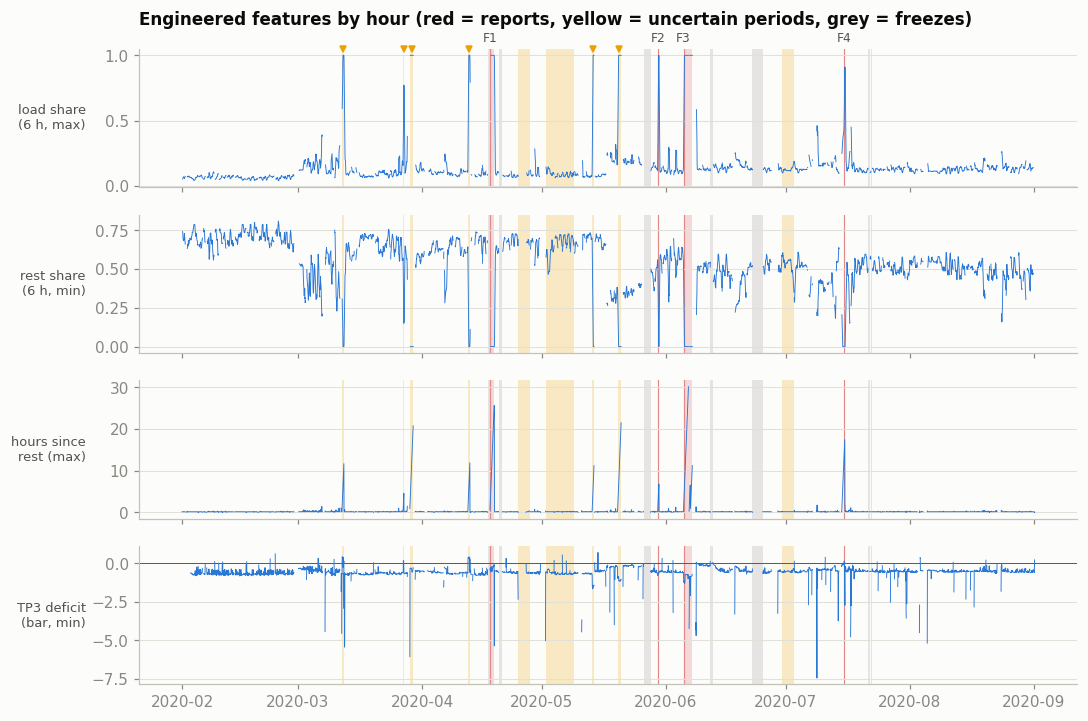

                     deficit (bar)         zone  missing points gap before (min) resumed (min before) TP3 at resume (bar)  TP3 lowest (bar)  motor loaded (%)  load commanded, motor off (%)
window end                                                                                                                                                                                  
2020-07-08 18:06:00          -7.44       buffer               0                                                                        1.20                44                              0
2020-03-28 23:16:00          -6.06     gap_edge             297              856                   10                0.73              0.73               100                              0
2020-03-12 15:39:00          -5.44     gap_edge             286               48                   10                0.93              0.93                85                              0
2020-04-19 02:47:00          -5.36      failure        

In [42]:
# Hourly extremes in the direction each channel moves in a leak.
hourly_feats = (windows.set_index('window_end')
                [['load_share_6h', 'rest_share_6h', 'hours_since_rest', 'tp3_deficit_7d']]
                .resample('h').agg({'load_share_6h': 'max', 'rest_share_6h': 'min',
                                    'hours_since_rest': 'max', 'tp3_deficit_7d': 'min'}))
labels = ['load share\n(6 h, max)', 'rest share\n(6 h, min)', 'hours since\nrest (max)', 'TP3 deficit\n(bar, min)']
fig, axes = plt.subplots(4, 1, figsize=(11, 7.5), sharex=True)
for ax, col, lab in zip(axes, hourly_feats.columns, labels):
    ax.plot(hourly_feats.index, hourly_feats[col], color=BLUE, lw=0.6, zorder=3)
    for s, e, _ in UNCERTAIN:
        ax.axvspan(s, e, color=YELLOW, alpha=0.22, lw=0)
    for s, e, _ in FAILURE_WINDOWS:
        ax.axvline(s, color=CRITICAL, lw=0.8, alpha=0.5, zorder=1)
    shade_failures(ax)
    shade_freezes(ax)
    ax.set_ylabel(lab, rotation=0, ha='right', va='center', fontsize=8.5)
    ax.grid(axis='x', visible=False)
top = axes[0].get_xaxis_transform()
for i, (s, e, _) in enumerate(FAILURE_WINDOWS, start=1):
    axes[0].text(s, 1.03, f'F{i}', transform=top, ha='center', va='bottom', fontsize=8, color=INK2)
for s, e, tag in UNCERTAIN:
    if tag != 'lps_heavy':
        axes[0].plot([s + (e - s) / 2], [1.0], marker='v', ms=4, color=YELLOW, transform=top, clip_on=False)
axes[3].axhline(0, color=INK2, lw=0.6)
axes[0].set_title('Engineered features by hour (red = reports, yellow = uncertain periods, '
                  'grey = freezes)', pad=16)
fig.align_ylabels(axes)
plt.show()

# Recording gaps of 5 minutes or more (freezes excluded), with TP3 on either side.
tp3v, missing = np.where(grid_valid, grid.TP3.to_numpy(), np.nan), ~grid_valid
rid = np.cumsum(np.r_[True, missing[1:] != missing[:-1]])
rlen = np.bincount(rid)[rid]
masked_run = np.bincount(rid, weights=(grid.zone_code.to_numpy() == CODE['masked'])) > 0
gap_rows = []
for i in np.flatnonzero(missing & np.r_[True, ~missing[:-1]]):
    n = rlen[i]
    if 0 < i and i + n < len(grid) and not masked_run[rid[i]] and (n + 1) * 10 >= 300:
        gap_rows.append({'gap start': grid.index[i], 'resume': grid.index[i + n], 'minutes': round((n + 1) / 6, 1),
                         'TP3 before': tp3v[i - 1], 'TP3 after': tp3v[i + n]})
gaps5 = pd.DataFrame(gap_rows)
gaps5['bar lost'] = gaps5['TP3 before'] - gaps5['TP3 after']

# The deepest pressure dips: the lowest window of each day, then the ten lowest days, with
# what the raw channels do in the hour before each window ends.
deficit = windows.set_index('window_end').tp3_deficit_7d.dropna()
deepest = deficit.loc[deficit.groupby(deficit.index.floor('D')).idxmin().to_numpy()].nsmallest(10)
zone_at = windows.set_index('window_end').zone_detail
dip_rows = []
for end, value in deepest.items():
    hour = grid.loc[end - pd.Timedelta(hours=1):end - pd.Timedelta(STEP)]
    raw = hour[hour.observed | hour.bridged]
    gap = gaps5[(gaps5.resume > end - pd.Timedelta(hours=1)) & (gaps5.resume < end)].tail(1)
    dip_rows.append({'window end': end, 'deficit (bar)': round(value, 2), 'zone': zone_at.loc[end],
                     'missing points': len(hour) - len(raw),
                     'gap before (min)': f'{gap.minutes.iat[0]:.0f}' if len(gap) else '',
                     'resumed (min before)': f'{(end - gap.resume.iat[0]).total_seconds() / 60:.0f}' if len(gap) else '',
                     'TP3 at resume (bar)': f'{gap["TP3 after"].iat[0]:.2f}' if len(gap) else '',
                     'TP3 lowest (bar)': round(raw.TP3.min(), 2),
                     'motor loaded (%)': round(100 * (raw.Motor_current > LOADED_A).mean()),
                     'load commanded, motor off (%)':
                         round(100 * ((raw.DV_eletric == 1) & (raw.Motor_current < REST_A)).mean())})
print(pd.DataFrame(dip_rows).set_index('window end').to_string())
off = windows[windows.cmd_motor_off > 0]
print(f'deepest deficit in a window with load commanded and the motor off: {off.tp3_deficit_7d.min():.2f} bar '
      f'({off.window_end[off.tp3_deficit_7d.idxmin()]:%b %d %H:%M})')

# Pressure lost across recording gaps of 5 to 120 minutes, a leak-down test nobody planned,
# with the zone of the first complete window after each.
leak_down = gaps5[gaps5.minutes <= 120].copy()
first_after = windows.window_start.searchsorted(leak_down.resume)
leak_down['next window'] = [windows.zone_detail.iat[k] if k < len(windows) else '' for k in first_after]
print(f'\nTP3 lost across the {len(leak_down)} recording gaps of 5 to 120 min: median '
      f'{leak_down["bar lost"].median():.2f} bar; the largest losses:')
print(leak_down.nlargest(6, 'bar lost').set_index('gap start').drop(columns='resume').round(2).to_string())

# The Jul 8 drop in 5-minute means.
print('\nJul 8, 17:40 to 18:25 (5-minute means):')
jul8 = grid.loc['2020-07-08 17:40':'2020-07-08 18:24:50', ['TP3', 'Motor_current', 'DV_eletric', 'LPS']]
print(jul8.resample('5min').mean().round(2).T.to_string())

### 8.4 · Redundancy

On healthy windows, 13 feature pairs correlate at |r| ≥ 0.9. Six pair TP2 with H1, which mirror each
other (Section 3), and two more pair statistics within TP2 or within H1. The rest are oil
temperature's mean against its minimum and maximum, load share against rest share, TP3's slope
against oil temperature's, and `tp3_deficit_7d` against `TP3_mean` (r = 0.98). That last pair tracks
because the 7-day baseline moves slowly, and on 2020 data the deficit separates the episodes no
better. We keep both for now: in the 2022 transfer test a shifted pressure baseline would move
`TP3_mean` for good but the deficit only for a week, which is worth testing before dropping either.

For the tabular baselines (z-score, PCA), a greedy pass that keeps the first feature of each
remaining pair suggests nine drops, printed below. The deep detectors take the sequences and need no
pruning. The two data-quality flags are non-zero in under half a percent of healthy windows, which is
why they stay out of the detector.

In [43]:
sample = healthy_w.iloc[::5][FEATURES]
corr = sample.corr()
pairs = [(a, b, round(corr.loc[a, b], 3)) for i, a in enumerate(FEATURES) for b in FEATURES[i + 1:]
         if abs(corr.loc[a, b]) >= 0.9]
spread = sample.quantile(0.75) - sample.quantile(0.25)
print('features with zero interquartile range on healthy windows: ' + ', '.join(spread.index[spread == 0]))
flags = (healthy_w[['cmd_motor_off', 'n_bridged']] > 0).mean()
print('healthy windows where a data-quality flag is non-zero: '
      + ', '.join(f'{k} {v:.2%}' for k, v in flags.items()))
drop = []
for a, b, r in sorted(pairs, key=lambda p: -abs(p[2])):
    if (a, b) == ('TP3_mean', 'tp3_deficit_7d') or a in drop or b in drop:
        continue
    drop.append(b)
print(f'{len(pairs)} pairs at |r| >= 0.9; suggested drops for the tabular baselines: ' + ', '.join(drop))
(pd.DataFrame(pairs, columns=['feature', 'redundant with', 'r on healthy windows'])
   .sort_values('r on healthy windows', key=abs, ascending=False).reset_index(drop=True))

features with zero interquartile range on healthy windows: cmd_motor_off, n_bridged
healthy windows where a data-quality flag is non-zero: cmd_motor_off 0.40%, n_bridged 0.17%
13 pairs at |r| >= 0.9; suggested drops for the tabular baselines: H1_std, H1_min, TP2_max, H1_slope, Oil_temperature_max, rest_share_6h, H1_mean, Oil_temperature_min, Oil_temperature_slope


,feature,redundant with,r on healthy windows
0,TP2_std,H1_std,0.996
1,TP2_max,H1_min,-0.989
2,TP3_mean,tp3_deficit_7d,0.982
3,TP2_std,TP2_max,0.966
4,TP2_max,H1_std,0.959
5,TP2_slope,H1_slope,-0.953
6,TP2_std,H1_min,-0.944
7,H1_std,H1_min,-0.942
8,Oil_temperature_mean,Oil_temperature_max,0.939
9,load_share_6h,rest_share_6h,-0.927


### 8.5 · Leakage checks

Four checks, all printed below:

1. **Causality.** At twelve cut instants, the features are rebuilt two ways and compared with the
   full run over the last day before the cut. The cuts cover ordinary days, a load episode, the four
   reports and F4's guard band, 11 minutes after a restart, 4 hours after a freeze and 5 minutes
   after a bridged point; the table gives each cut's zone and how many of the compared windows are
   complete. On a grid truncated
   at the cut, every window that ends by the cut matches, so no feature reads past a window's last
   point. On a grid rebuilt from the raw rows before the cut, every window that ends 30 s or more
   before it matches, so bridging is the only step there that looks ahead. The largest difference,
   under 3e-14, is floating-point rounding.
2. **No labels.** No zone, event, block, look-back, split or time column is among the features.
3. **Hindsight upstream.** Bridging fills at most two points from a later sample, so a streaming
   scorer has to wait up to 20 s after a window ends before it can score it. The freeze masks use
   hindsight too: a run is only known to be a freeze once it has lasted 30 minutes, so the streaming
   path needs its own freeze check.
4. **Scaling.** The scaling statistics saved with the features come from the 75,697 negative windows
   of the fit half that read no test block, so one scaler is valid in every fold: median and
   interquartile range overall, plus per-regime medians. The interquartile range is left empty for
   the two flags, where it is zero.

In [44]:
# 1. Causality, tested two ways at twelve cut instants: ordinary days, a load episode, the
#    four reports and F4's guard band, and minutes after a restart, a freeze and a bridged
#    point. Each test uses the 8 days before the cut and compares the windows of the last day
#    with the full run.
#    (a) Features from a grid truncated at the cut match for every window that ends by the cut:
#        window_features reads nothing past a window's last point.
#    (b) A grid rebuilt from the raw rows before the cut matches for every window that ends at
#        least 30 s before it: bridging is the only step that looks ahead.
CUTS = [T(c) for c in ['2020-02-20 08:00', '2020-03-12 06:00', '2020-04-18 12:00', '2020-05-10 23:00',
                       '2020-05-30 03:00', '2020-06-06 20:00', '2020-06-08 12:00', '2020-06-25 09:00',
                       '2020-07-15 12:00', '2020-07-15 17:30', '2020-08-20 10:00']]
bridged_at = grid.index[grid.bridged.to_numpy()]
if len(bridged_at):
    CUTS.append(bridged_at[len(bridged_at) // 2] + pd.Timedelta(STEP))
SPAN, DAY = pd.Timedelta(days=8, hours=1), pd.Timedelta(days=1)
F_FULL = feats.to_numpy(float)

def compare(sub_grid, keep_until):
    # Features on sub_grid against the full run, for windows ending in (cut - 1 day, keep_until].
    ends = window_ends(sub_grid)
    f_sub = window_features(sub_grid, ends).to_numpy(float)
    end_t = sub_grid.index[ends] + pd.Timedelta(STEP)
    keep = (end_t > cut - DAY) & (end_t <= keep_until)
    pos = grid.index.searchsorted(sub_grid.index[0]) + ends[keep]
    rows = np.searchsorted(win_end_pos, pos)
    assert (win_end_pos[rows] == pos).all()
    a, b = f_sub[keep], F_FULL[rows]
    same_nan = bool((np.isnan(a) == np.isnan(b)).all())
    n_complete = int(windows_all.complete.to_numpy()[rows].sum())
    return int(keep.sum()), n_complete, float(np.nanmax(np.abs(a - b))), same_nan

causal = []
for cut in CUTS:
    lo = cut - SPAN
    sub = grid.iloc[grid.index.searchsorted(lo):grid.index.searchsorted(cut)]
    n_a, full_a, diff_a, nan_a = compare(sub, cut)
    raw_rows = ((df.timestamp >= lo) & (df.timestamp < cut)).to_numpy()
    n_b, full_b, diff_b, nan_b = compare(to_grid(df[raw_rows], frozen[raw_rows]), cut - pd.Timedelta(seconds=30))
    before = grid.index.searchsorted(cut) - 1
    causal.append({'cut': cut, 'zone at cut': ZONE_DETAIL[grid.zone_code.iat[before]],
                   'min since missing data': round((cut - gap_t[gap_t.searchsorted(cut) - 1]).total_seconds() / 60),
                   'windows (a)': n_a, 'complete (a)': full_a, 'largest difference (a)': diff_a,
                   'windows (b)': n_b, 'largest difference (b)': diff_b, 'same missing values': nan_a and nan_b})
causal = pd.DataFrame(causal).set_index('cut')
print(causal.to_string())
print(f'all {len(CUTS)} cuts match: {bool(((causal.filter(like="difference") < 1e-9).all(axis=None)) and causal["same missing values"].all())}')

# 2. No labels among the features.
label_cols = {'zone', 'zone_detail', 'regime', 'neg_split', 'window_start', 'window_end', 'event',
              *[f'{k}_F{i}' for k in ('block', 'lookback') for i in range(1, 5)]}
print('\nlabel or time columns among the features:', sorted(label_cols & set(FEATURES)) or 'none')

# 3. Bridging looks ahead by at most one gap of 30 s.
run_id = np.cumsum(np.r_[True, grid.bridged.to_numpy()[1:] != grid.bridged.to_numpy()[:-1]])
longest = int(np.bincount(run_id, weights=grid.bridged.to_numpy()).max())
print(f'longest bridged run: {longest} points ({longest * 10} s)')

# 4. Scaling statistics come from the fit half of the negative windows only, leaving out every
#    window whose look-back reaches a test block, so one scaler is valid in every fold.
fit_w = healthy_w[(healthy_w.neg_split == 'fit') & ~healthy_w.filter(like='lookback_F').any(axis=1)]
iqr = fit_w[FEATURES].quantile(0.75) - fit_w[FEATURES].quantile(0.25)
scaler = pd.DataFrame({'median': fit_w[FEATURES].median(), 'iqr': iqr.where(iqr > 0)})
for reg in ['light_duty', 'normal', 'dv_pressure_flat']:
    scaler[f'median_{reg}'] = fit_w.loc[fit_w.regime == reg, FEATURES].median()
print(f'scaler from {len(fit_w):,} fit-half negative windows with no look-back into a test block; '
      'IQR left empty where it is zero: '
      + ', '.join(iqr.index[iqr == 0]))
scaler.loc[['load_share_6h', 'rest_share_6h', 'hours_since_rest', 'tp3_deficit_7d', 'Oil_temperature_mean']].round(3)

                             zone at cut  min since missing data  windows (a)  complete (a)  largest difference (a)  windows (b)  largest difference (b)  same missing values
cut                                                                                                                                                                          
2020-02-20 08:00:00             negative                     206         1440           909            1.421085e-14         1439            1.421085e-14                 True
2020-03-12 06:00:00  uncertain:load_held                     442         1440           829            1.421085e-14         1439            1.421085e-14                 True
2020-04-18 12:00:00              failure                     696         1440           687            4.440892e-15         1439            4.440892e-15                 True
2020-05-10 23:00:00             gap_edge                      11         1440            68            1.421085e-14         1439  

,median,iqr,median_light_duty,median_normal,median_dv_pressure_flat
load_share_6h,0.098,0.053,0.060,0.092,0.119
rest_share_6h,0.624,0.169,0.714,0.641,0.534
hours_since_rest,0.000,0.058,0.000,0.000,0.000
tp3_deficit_7d,0.024,0.583,-0.010,0.042,0.020
Oil_temperature_mean,60.808,8.392,56.815,59.754,65.641


### 8.6 · Saved for the modeling phase

Everything the next phase needs goes to a `processed/` folder beside the data file, which is
`data/processed/` in the repository and ignored by git:

- `grid_10s.csv.gz`: the 10 s grid with the observed and bridged flags and both zone columns, one
  row per grid point;
- `windows_10min.csv.gz`: one row per complete window, with zones, regime, event, test blocks,
  look-back flags, the fit/calibrate split and all 32 features;
- `feature_dictionary.csv` and `scaler_negative.csv`;
- `manifest.json`: the source file's SHA-256, every zone and fold input (failure windows, repairs,
  masks, uncertain and grey periods, the 190 gap edges, regime splits, test blocks), the feature
  parameters, and the counts a pipeline test should reproduce.

The two tables are gzip-compressed CSV and the rest plain CSV and JSON, so reading them needs nothing
beyond pandas.

In [45]:
import hashlib
import json

OUT = DATA_PATH.parent / 'processed'
OUT.mkdir(parents=True, exist_ok=True)
gz = {'method': 'gzip', 'compresslevel': 1}
grid.drop(columns='zone_code').to_csv(OUT / 'grid_10s.csv.gz', float_format='%.7g', compression=gz)
windows.to_csv(OUT / 'windows_10min.csv.gz', index=False, float_format='%.6g', compression=gz)
FEATURE_DICT.to_csv(OUT / 'feature_dictionary.csv', index=False)
scaler.to_csv(OUT / 'scaler_negative.csv', index_label='feature')

sha = hashlib.sha256()
with open(DATA_PATH, 'rb') as fh:
    for chunk in iter(lambda: fh.read(1 << 20), b''):
        sha.update(chunk)
iso = lambda t: None if t is None else pd.Timestamp(t).isoformat()
manifest = {
    'created_by': 'notebooks/metropt3_eda.ipynb, Sections 7-8',
    'source': {'file': DATA_PATH.name, 'rows': len(df), 'sha256': sha.hexdigest()},
    'grid': {'step': STEP, 'bins': 'epoch-aligned; analog mean, digital last', 'max_bridge_s': MAX_BRIDGE_S,
             'bridge_rule': 'interior runs with (run + 1) x step <= max_bridge_s',
             'freeze_masks': [[iso(s), iso(e)] for s, e in FREEZE_MASKS]},
    'zones': {'precedence': ZONE_DETAIL[::-1], 'guard_band': [str(GUARD_BEFORE), str(GUARD_AFTER)],
              'healthy_buffer': {'before_report': str(BUFFER_BEFORE), 'after_repair': str(BUFFER_AFTER),
                                 'no_repair': 'counted from the report end'},
              'gap_edge': {'after_gaps_of': str(STOP_MIN), 'length': str(GAP_EDGE),
                           'gaps': 'raw timestamp gaps; freezes keep their timestamps and are not gaps',
                           'spans': [[iso(s), iso(e)] for s, e in GAP_EDGES]},
              'failures': [{'id': f'F{i}', 'start': iso(s), 'end': iso(e), 'repair': iso(r)}
                           for i, ((s, e, _), r) in enumerate(zip(FAILURE_WINDOWS, REPAIRS), start=1)],
              'uncertain_periods': [[iso(s), iso(e), tag] for s, e, tag in UNCERTAIN],
              'grey_periods': [[iso(s), iso(e)] for s, e in GREY],
              'regime_splits': [iso(t) for t in REGIME_SPLITS]},
    'windows': {'length': str(WIN_LEN), 'stride': '1min', 'complete': 'all points observed or bridged',
                'lookback': str(LOOKBACK),
                'after_uncertain': 'negative window whose look-back reaches an uncertain period or a report'},
    'folds': {'test_blocks': {k: [iso(a), iso(b)] for k, (a, b) in BLOCKS.items()}, 'paired': ['F2', 'F3'],
              'lookback_days': 7,
              'lookback_columns': 'negative windows whose 7-day look-back reaches a block; leave them out of that fold',
              'neg_split': 'ISO week of window_start: even = fit, odd = calibrate', 'none_label': 'none'},
    'features': {'inputs': INPUTS, 'loaded_above_A': LOADED_A, 'stopped_below_A': REST_A,
                 'share_window': '6h', 'share_min_coverage': 0.5, 'stop': str(STOP_MIN) + ' gap or freeze',
                 'deficit_baseline': '7 days before the window', 'deficit_min_coverage': 0.25},
    'expected_counts': {'grid_points': len(grid), 'complete_windows': len(windows),
                        'negative_windows': int((windows.zone == 'negative').sum()),
                        'non_overlapping_negative': len(aligned_neg),
                        'non_overlapping_negative_section6_exclusions': len(base)},
    'outputs': {'grid_10s.csv.gz': {'rows': len(grid), 'columns': grid.shape[1]},   # timestamp in, zone_code out
                'windows_10min.csv.gz': {'rows': len(windows), 'columns': windows.shape[1]},
                'feature_dictionary.csv': {'rows': len(FEATURE_DICT)},
                'scaler_negative.csv': {'rows': len(scaler),
                                        'fitted_on': 'negative windows, fit half, no look-back into a test block'}},
}
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2))

back = pd.read_csv(OUT / 'windows_10min.csv.gz', nrows=1000)
print('read back windows_10min.csv.gz: columns match' if list(back.columns) == list(windows.columns)
      else 'read back: COLUMN MISMATCH')
pd.DataFrame({'MB': {p.name: round(p.stat().st_size / 1e6, 1) for p in sorted(OUT.iterdir())}})

read back windows_10min.csv.gz: columns match


,MB
feature_dictionary.csv,0.0
grid_10s.csv.gz,28.2
manifest.json,0.0
scaler_negative.csv,0.0
windows_10min.csv.gz,24.3


## 9 · Fact sheet and implications

In [46]:
print('EDA fact sheet (revised and extended 2026-09-27)')
print('----------------------------------------------')
print(f'records             : {len(df):,}')
print(f'span                : {df.timestamp.min():%Y-%m-%d} -> {df.timestamp.max():%Y-%m-%d}, '
      'fixed UTC clock')
print(f'sampling step       : {step:g} s ({1 / step:.3g} Hz); real steps 9-10 s')
print(f'gaps > {GAP_FACTOR}x step      : {len(big):,} ({big.delta_s.sum() / 3600:,.1f} h); '
      f'{len(long_)} of 12 h or more ({long_.delta_s.sum() / 3600:.0f} h)')
print(f'duplicated stamps   : {dup_ts:,}')
print(f'logger freezes      : {len(freezes)} runs, {freezes.hours.sum():.1f} h, '
      f'{frozen.mean():.1%} of rows')
fail_h = sum((e - s).total_seconds() for s, e, _ in FAILURE_WINDOWS) / 3600
print(f'reported failures   : {len(FAILURE_WINDOWS)} air leaks, {fail_h:.1f} h of report windows')
n_fall = int((unrep['dTP3 vs prior 7 d (bar)'] < 0).sum())
print(f'unreported episodes : {len(unrep)} of continuous load, {n_fall} with falling TP3')
print(f'healthy windows (6) : {int(w.healthy.sum()):,} x 10 min (~{w.healthy.sum() * 10 / 1440:.0f} '
      f'days); longest unbroken stretch {run_len.max() * 10 / 60:.0f} h')
print(f'10 s grid           : {len(grid):,} points; {int(grid.bridged.sum())} bridged, '
      f'{(~grid_valid).sum() / 360:,.0f} h missing')
print(f'model-ready windows : {len(windows):,} complete (10 min, 1 min stride), '
      f'{int((windows.zone == "negative").sum()):,} negative, {len(aligned_neg):,} of them non-overlapping')
print(f'features per window : {len(FEATURES)} ({(FEATURE_DICT.role == "engineered").sum()} engineered, '
      f'{(FEATURE_DICT.role == "data-quality flag").sum()} data-quality flags)')
print(f'saved to            : {OUT}')

EDA fact sheet (revised and extended 2026-09-27)
----------------------------------------------
records             : 1,516,948
span                : 2020-02-01 -> 2020-09-01, fixed UTC clock
sampling step       : 10 s (0.1 Hz); real steps 9-10 s
gaps > 5x step      : 331 (909.5 h); 15 of 12 h or more (340 h)
duplicated stamps   : 0
logger freezes      : 10 runs, 169.8 h, 3.3% of rows
reported failures   : 4 air leaks, 87.5 h of report windows
unreported episodes : 6 of continuous load, 3 with falling TP3
healthy windows (6) : 18,131 x 10 min (~126 days); longest unbroken stretch 75 h
10 s grid           : 1,841,760 points; 86 bridged, 1,078 h missing
model-ready windows : 239,172 complete (10 min, 1 min stride), 177,973 negative, 17,810 of them non-overlapping
features per window : 32 (5 engineered, 2 data-quality flags)
saved to            : ../data/processed


### What the data establishes

1. **Sampling rate: 0.1 Hz** — median delta 10 s; real steps are 9–10 s, and almost all of the
   11–13 s steps (99.5 %) are logger freezes. The proposal's 1 Hz mention is corrected accordingly.
2. **Record count: 1,516,948** — exact match to the UCI figure; the PDF's 15,169,480 is the 1 Hz count.
3. **Clean file, gappy and partly frozen recording** — no nulls, no duplicate timestamps, strictly
   binary digitals; ~38 days missing across 331 gaps, nearly half of it in 3–12 h stops, most of them
   overnight; 169.8 h of logger freezes that must be masked before anything else.
4. **Failure signature: continuous load replaces cycling** — and it appears six more times with no
   report, three of them with the falling pressure of a leak.
5. **Lead time is event-specific.** Cycling carries none once freezes are masked. Before F4 the
   compressor stops resting about 14 hours out, and the change began inside a 14-hour recording gap,
   so the true lead may be longer. The rule's F3 alarm is one long charge two days out; F2's lead-up
   shifts moderately on the load features without tripping the rule (Section 8.2); and most of the
   last 24 h before F1 are frozen.
6. **Model-ready data exists.** 239,172 complete 10-minute windows (1-minute stride) on a regular
   10 s grid, 177,973 of them negative, with zones, evaluation blocks, look-back flags, a
   fit/calibrate split and 32 features each, causal apart from bridging and the freeze masks, saved
   to `data/processed/`.
7. **Open items** — whether the May 13–14 and May 19–20 episodes count toward F2; the load-share
   threshold under leave-one-event-out; the guard-band rule for day-granular labels; whether
   DV_pressure stays out for good or is split at Jun 8 (the features leave it out, the grid keeps
   it); the Jul 8 pressure drop a week before F4 and the four large pressure losses across recording
   gaps.

### What this feeds in PdM-Agent

- **R1b models** — read `data/processed/`: the window table for the z-score and PCA baselines, the
  grid for sequence models. Fit on negative `fit` windows and set thresholds on negative `calibrate`
  windows, leaving out `lookback_F{i}` in fold *i* when the model reads the window table. Test on
  `block_F{i}`, score positives by `event`, and report F2 and F3 as a pair.
- **`pdm_common` (build guide R1a.4–R1a.5)** — takes the eight functions of Sections 2.2 and 7–8,
  with the notebook constants moved into the profile and events files. Its tests should reproduce
  the counts in `manifest.json`: 239,172 complete windows, 177,973 negative and 17,810
  non-overlapping negative ones (18,130 under Section 6's exclusions).
- **`events.yaml` v0.2** — repair hours from the PDF; the ten freeze masks as `data_quality_masks`;
  the six episodes as uncertain periods tagged `probable_leak` or `load_held` (the Jun 12–14 and
  Jul 24–26 entries go, since their reason was the freeze artifact); Jun 8 11:48–16:00 grey; gap
  edges of 15 minutes after recording gaps of 30 minutes or more; a `dv_pressure_flat` regime from
  Jun 8 16:00.
- **`asset_profile.yaml` v0.2** — `source_timezone: UTC`; the freeze rule (30 min, 15 s); detector
  inputs TP2, TP3, H1, Oil_temperature and Motor_current (DV_pressure out, Reservoirs kept for the
  divergence check); `comp_cycle_rate` replaced by `load_share_6h` and `rest_share_6h`, both
  computed from motor current.
- **Diagnostic checks** — before a pressure drop is read as a leak, check whether recording has
  just resumed after a gap and whether load is commanded with the motor off (`cmd_motor_off`);
  restarts explain nine of the ten deepest dips (Section 8.3). A leak-down check, the pressure lost
  across a recording gap, is worth adding: four of 149 gaps of 5 to 120 minutes lose 6.7–8.7 bar
  against a median of 0.39.
- **Evaluation** — lead time at 2, 24 and 72 h under leave-one-event-out; FAR per week of negative
  time, reported with and without the uncertain periods; the May episodes decided before any lead
  time is quoted.

### Action plan

1. **First action (2 minutes, today):** load `data/processed/windows_10min.csv.gz` and filter
   `zone == 'negative'`, `neg_split == 'fit'` and no `lookback_F*` flag. That is the set
   `scaler_negative.csv` was fitted on, so it is the z-score baseline's training set in every fold.
2. **If** the May episodes are not settled in the first 10 minutes of the next sync, **then** we
   keep them uncertain, report them as a separate line, and move on.
3. **Version Zero this week:** a z-score baseline on the saved windows, with thresholds from the
   `calibrate` half (again without look-back flags) and scores on each fold's test block, F2 and F3
   as a pair. Ugly is fine.
4. **Hard thing first:** move the eight preprocessing functions into `pdm_common` with tests that
   reproduce the counts in `manifest.json`, before the Version Zero grows into the R1b harness.
5. **Deadlines:** `events.yaml` v0.2 by Sep 29, `asset_profile.yaml` v0.2 by Sep 30, and the
   harness running before the Oct 11 detector freeze.
6. **Accountability:** the executed notebook and `manifest.json` go to Ashok and Gayatri before the
   next sync, with the two decisions that need the team named: the May episodes and DV_pressure.